## Overall EDA

In [376]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 60)

In [377]:
np.random.seed(42)

In [378]:

df=pd.read_csv('train_data.csv')


In [379]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 39 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   id                            1048575 non-null  int64  
 1   title                         1048568 non-null  object 
 2   quality                       1048575 non-null  object 
 3   theatrical                    1048575 non-null  bool   
 4   movie_valence                 253156 non-null   float64
 5   movie_vad_valence             256854 non-null   float64
 6   movie_vad_arousal             256854 non-null   float64
 7   movie_vad_dominance           256854 non-null   float64
 8   movie_intensity_anger         180388 non-null   float64
 9   movie_intensity_anticipation  180388 non-null   float64
 10  movie_intensity_disgust       180388 non-null   float64
 11  movie_intensity_fear          180388 non-null   float64
 12  movie_intensity_joy         

In [380]:
df.head()

,id,title,quality,theatrical,movie_valence,movie_vad_valence,movie_vad_arousal,movie_vad_dominance,movie_intensity_anger,movie_intensity_anticipation,movie_intensity_disgust,movie_intensity_fear,movie_intensity_joy,movie_intensity_sadness,movie_intensity_surprise,movie_intensity_trust,movie_scl_shift,movie_scl_coverage,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages
0,565770,Blue Beetle,real_confident,True,0.434939,0.445939,0.070364,0.405667,0.058714,0.077000,0.062571,0.216500,0.231857,0.000000,0.000000,0.209143,-0.061000,0.266667,7.139,1023,Released,2023-08-16,124818235,128,False,/1syW9SNna38rSl9fnXwc9fP7POW.jpg,120000000,https://www.dc.com/bluebeetle,tt9362930,en,Blue Beetle,Recent college grad Jaime Reyes returns home full of asp...,2994.357,/mXLOHHc1Zeuwsl4xYKjKh2280oL.jpg,Jaime Reyes is a superhero whether he likes it or not.,"Action, Science Fiction, Adventure","Warner Bros. Pictures, The Safran Company, DC Films",United States of America,"English, Portuguese, Spanish"
1,980489,Gran Turismo,real_confident,True,0.508375,0.494900,0.231700,0.279400,0.000000,0.000000,0.000000,0.000000,0.347667,0.000000,0.000000,0.541833,0.000000,0.333333,8.068,702,Released,2023-08-09,114800000,135,False,/xFYpUmB01nswPgbzi8EOCT1ZYFu.jpg,60000000,https://www.granturismo.movie,tt4495098,en,Gran Turismo,The ultimate wish-fulfillment tale of a teenage Gran Tur...,2680.593,/51tqzRtKMMZEYUpSYkrUE7v9ehm.jpg,From gamer to racer.,"Action, Drama, Adventure","PlayStation Productions, 2.0 Entertainment, Columbia Pic...",United States of America,"English, German, Japanese"
2,968051,The Nun II,real_confident,True,-0.132556,-0.153909,0.115182,0.198364,0.319818,0.097273,0.236455,0.365773,0.000000,0.261364,0.117909,0.140636,0.000000,0.461538,6.545,365,Released,2023-09-06,231200000,110,False,/53z2fXEKfnNg2uSOPss2unPBGX1.jpg,38500000,https://www.warnerbros.com/movies/nun2,tt10160976,en,The Nun II,"In 1956 France, a priest is violently murdered, and Sist...",1692.778,/c9kVD7W8CT5xe4O3hQ7bFWwk68U.jpg,Confess your sins.,"Horror, Mystery, Thriller","New Line Cinema, Atomic Monster, The Safran Company",United States of America,"English, French"
3,615656,Meg 2: The Trench,real_confident,True,-0.003150,0.100458,0.067333,0.172458,0.000000,0.146500,0.000000,0.000000,0.071500,0.097750,0.000000,0.107500,0.000000,0.285714,6.912,2034,Released,2023-08-02,384056482,116,False,/5mzr6JZbrqnqD8rCEvPhuCE5Fw2.jpg,129000000,https://www.themeg.movie,tt9224104,en,Meg 2: The Trench,An exploratory dive into the deepest depths of the ocean...,1567.273,/4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg,Back for seconds.,"Action, Science Fiction, Horror","Apelles Entertainment, Warner Bros. Pictures, di Bonaven...","China, United States of America",English
4,762430,Retribution,real_confident,True,-0.300000,-0.318333,0.316333,0.096667,0.713667,0.000000,0.127667,0.749000,0.000000,0.680333,0.395667,0.044333,-0.008583,0.857143,6.816,258,Released,2023-08-23,12905464,91,False,/iiXliCeykkzmJ0Eg9RYJ7F2CWSz.jpg,20000000,https://iiil.io/jCT7,tt6906292,en,Retribution,"When a mysterious caller puts a bomb under his car seat,...",1547.220,/oUmmY7QWWn7OhKlcPOnirHJpP1F.jpg,All roads lead to the truth.,"Action, Mystery, Thriller, Crime","StudioCanal, The Picture Company, Ombra Films","France, United States of America","English, German"


In [381]:
null_columns=[col for col in df.columns if df[col].isnull().any()]

### Null drops

In [382]:
df.isnull().sum().sort_values()

id                                   0
popularity                           0
original_language                    0
budget                               0
runtime                              0
revenue                              0
status                               0
vote_average                         0
vote_count                           0
theatrical                           0
quality                              0
title                                7
original_title                       7
adult                             1362
release_date                    147908
overview                        200765
poster_path                     325029
genres                          340773
spoken_languages                420576
production_countries            444505
imdb_id                         467022
production_companies            593787
backdrop_path                   764862
movie_scl_coverage              777899
movie_vad_arousal               791721
movie_vad_valence        

In [383]:
no_null_cols = [
    'id', 'quality', 'theatrical', 'runtime', 'status',
    'revenue', 'vote_average', 'vote_count',
    'budget', 'original_language', 'popularity'
]
df_nulls = df.drop(columns=no_null_cols)

In [384]:
row_null_pct = df_nulls.isnull().mean(axis=1)

In [385]:
bins = pd.cut(
    row_null_pct,
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    include_lowest=True
)

distribution = bins.value_counts().sort_index()
distribution

(-0.001, 0.1]     75590
(0.1, 0.2]        75358
(0.2, 0.3]        26352
(0.3, 0.4]        31358
(0.4, 0.5]        39019
(0.5, 0.6]        75551
(0.6, 0.7]       282164
(0.7, 0.8]       317608
(0.8, 0.9]       125503
(0.9, 1.0]           72
Name: count, dtype: int64

In [386]:
df['row_null_pct'] = row_null_pct

In [387]:
df = df[df['row_null_pct'] <= 0.8].copy()

In [388]:
len(df)

923000

### 0.6 value analysis

In [389]:
df_06 = df[df['popularity'] == 0.6]
df_others = df[df['popularity'] != 0.6]

In [390]:
print(f"Total rows with 0.6 popularity: {len(df_06):,}")
print(f"Percentage of total dataset: {len(df_06)/len(df)*100:.2f}%\n")

Total rows with 0.6 popularity: 448,313
Percentage of total dataset: 48.57%



In [391]:
null_06 = df_06.isnull().mean()
null_others = df_others.isnull().mean()

comparison_nulls = pd.DataFrame({
    'Null % (0.6 Group)': null_06,
    'Null % (Others)': null_others,
    'Diff (0.6 is more empty by)': null_06 - null_others
}).sort_values(by='Null % (0.6 Group)', ascending=False)


In [392]:
print(comparison_nulls.head(30))

                              Null % (0.6 Group)  Null % (Others)  \
tagline                                 0.899265         0.786487   
movie_intensity_surprise                0.889354         0.724484   
movie_intensity_anger                   0.889354         0.724484   
movie_intensity_trust                   0.889354         0.724484   
movie_intensity_sadness                 0.889354         0.724484   
movie_intensity_joy                     0.889354         0.724484   
movie_intensity_fear                    0.889354         0.724484   
movie_intensity_disgust                 0.889354         0.724484   
movie_intensity_anticipation            0.889354         0.724484   
movie_scl_shift                         0.887233         0.727545   
homepage                                0.877628         0.861966   
backdrop_path                           0.824261         0.571577   
movie_valence                           0.820208         0.636491   
movie_vad_dominance               

## Column wise preprocesing

### Popularity

In [90]:
len(df[df['popularity']>100])

266

In [91]:
bins = [0, 10, 50, 100, 200, 500, df['popularity'].max()]
labels = ['0-10', '10-50', '50-100', '100-200', '200-500', '500+']
df['pop_range'] = pd.cut(df['popularity'], bins=bins, labels=labels)

range_analysis = df.groupby('pop_range').agg({
    'popularity': ['count', 'mean', 'std'],
    'vote_average': 'mean',
    'revenue': lambda x: (x > 0).mean() * 100
}).reset_index()

range_analysis.columns = ['Range', 'Count', 'Avg Pop', 'Std Pop', 'Avg Vote', '% Known Revenue']

range_analysis['% of Total Data'] = (range_analysis['Count'] / len(df)) * 100
print(range_analysis)

     Range   Count      Avg Pop     Std Pop  Avg Vote  % Known Revenue  \
0     0-10  899331     0.998769    1.164251  2.043266         1.287179   
1    10-50   14607    17.513297    7.903270  6.239384        51.050866   
2   50-100     607    67.502605   13.762945  6.755931        61.120264   
3  100-200     178   137.733562   30.071290  6.707736        42.134831   
4  200-500      65   308.507938   84.005434  6.933231        52.307692   
5     500+      23  1122.991348  641.856963  7.188609        65.217391   

   % of Total Data  
0        97.435645  
1         1.582557  
2         0.065764  
3         0.019285  
4         0.007042  
5         0.002492  


In [92]:
df = df[df['popularity'] <= 100].copy()

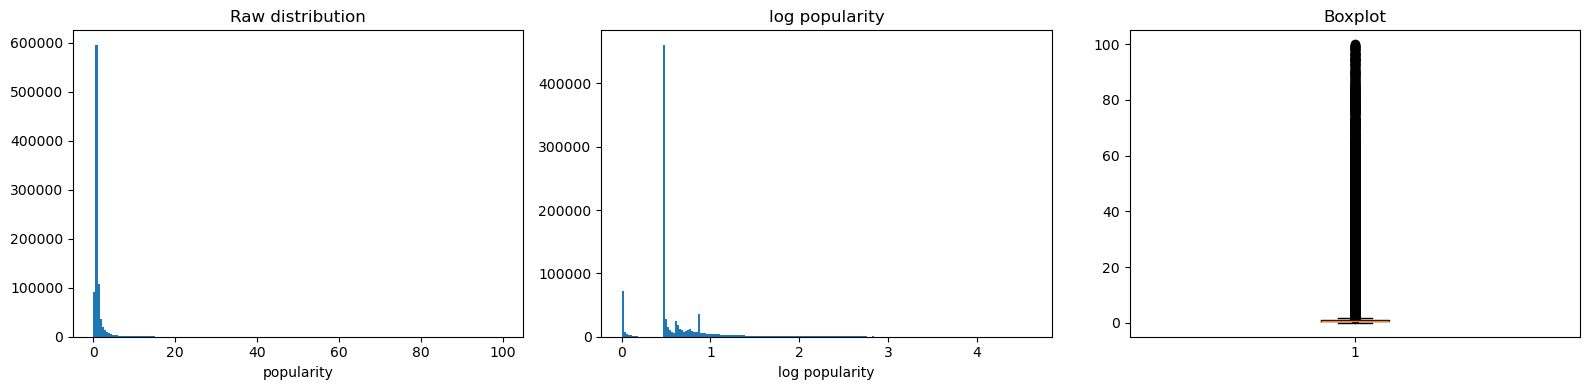

In [93]:
target = df['popularity']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(target, bins=200 )
axes[0].set_title('Raw distribution')
axes[0].set_xlabel('popularity')

axes[1].hist(np.log1p(target), bins=200)
axes[1].set_title('log popularity')
axes[1].set_xlabel('log popularity')

axes[2].boxplot(target)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()


In [94]:
df.loc[df['popularity']==df['popularity'].max()]

,id,title,quality,theatrical,movie_valence,movie_vad_valence,movie_vad_arousal,movie_vad_dominance,movie_intensity_anger,movie_intensity_anticipation,movie_intensity_disgust,movie_intensity_fear,movie_intensity_joy,movie_intensity_sadness,movie_intensity_surprise,movie_intensity_trust,movie_scl_shift,movie_scl_coverage,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,row_null_pct,pop_range
266,950071,Jaane Jaan,real_confident,True,0.27975,0.27975,-0.219,0.14375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.43,NaN,0.0,7.125,36,Released,2023-09-21,0,139,False,/2vLhatnKrAXGOesLth1lhz76JTg.jpg,0,https://www.netflix.com/title/81586376,tt15748830,hi,जाने जां,When a single mother her teenage daughter becomes ensnar...,99.944,/oaUOV9VCNM5MjrmonqgH4o3XNwQ.jpg,NaN,"Crime, Thriller","Kross Pictures, Northern Lights Films, 12th Street Enter...","India, South Korea, United States of America","English, Hindi",0.071429,50-100


In [95]:
df.drop(columns=['pop_range'],inplace=True)

In [96]:
df['popularity'].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.99, 1])

0.00     0.00000
0.25     0.60000
0.50     0.60000
0.75     1.03600
0.90     2.01300
0.99    13.53667
1.00    99.94400
Name: popularity, dtype: float64

In [97]:
pd.qcut(df['popularity'], q=10, duplicates='drop').value_counts()

popularity
(-0.001, 0.6]      539245
(0.871, 1.273]      92287
(2.013, 99.944]     92239
(1.273, 2.013]      92200
(0.626, 0.871]      91565
(0.6, 0.626]        15198
Name: count, dtype: int64

In [98]:
y = np.log1p(df['popularity'])
# bc howa right skewed

### Overall EDA

In [99]:
null_ratio = (df.isnull().sum() / len(df)).sort_values(ascending=False)
null_ratio_df = null_ratio.reset_index()
null_ratio_df.columns = ['column', 'null_ratio']
print(null_ratio_df)

                          column  null_ratio
0                       homepage    0.869713
1                        tagline    0.841419
2                movie_scl_shift    0.805263
3   movie_intensity_anticipation    0.804736
4       movie_intensity_surprise    0.804736
5        movie_intensity_sadness    0.804736
6            movie_intensity_joy    0.804736
7        movie_intensity_disgust    0.804736
8          movie_intensity_trust    0.804736
9          movie_intensity_anger    0.804736
10          movie_intensity_fear    0.804736
11                 movie_valence    0.725885
12           movie_vad_dominance    0.721879
13             movie_vad_arousal    0.721879
14             movie_vad_valence    0.721879
15            movie_scl_coverage    0.707052
16                 backdrop_path    0.694507
17          production_companies    0.508696
18                       imdb_id    0.387681
19          production_countries    0.349199
20              spoken_languages    0.327398
21        

In [100]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


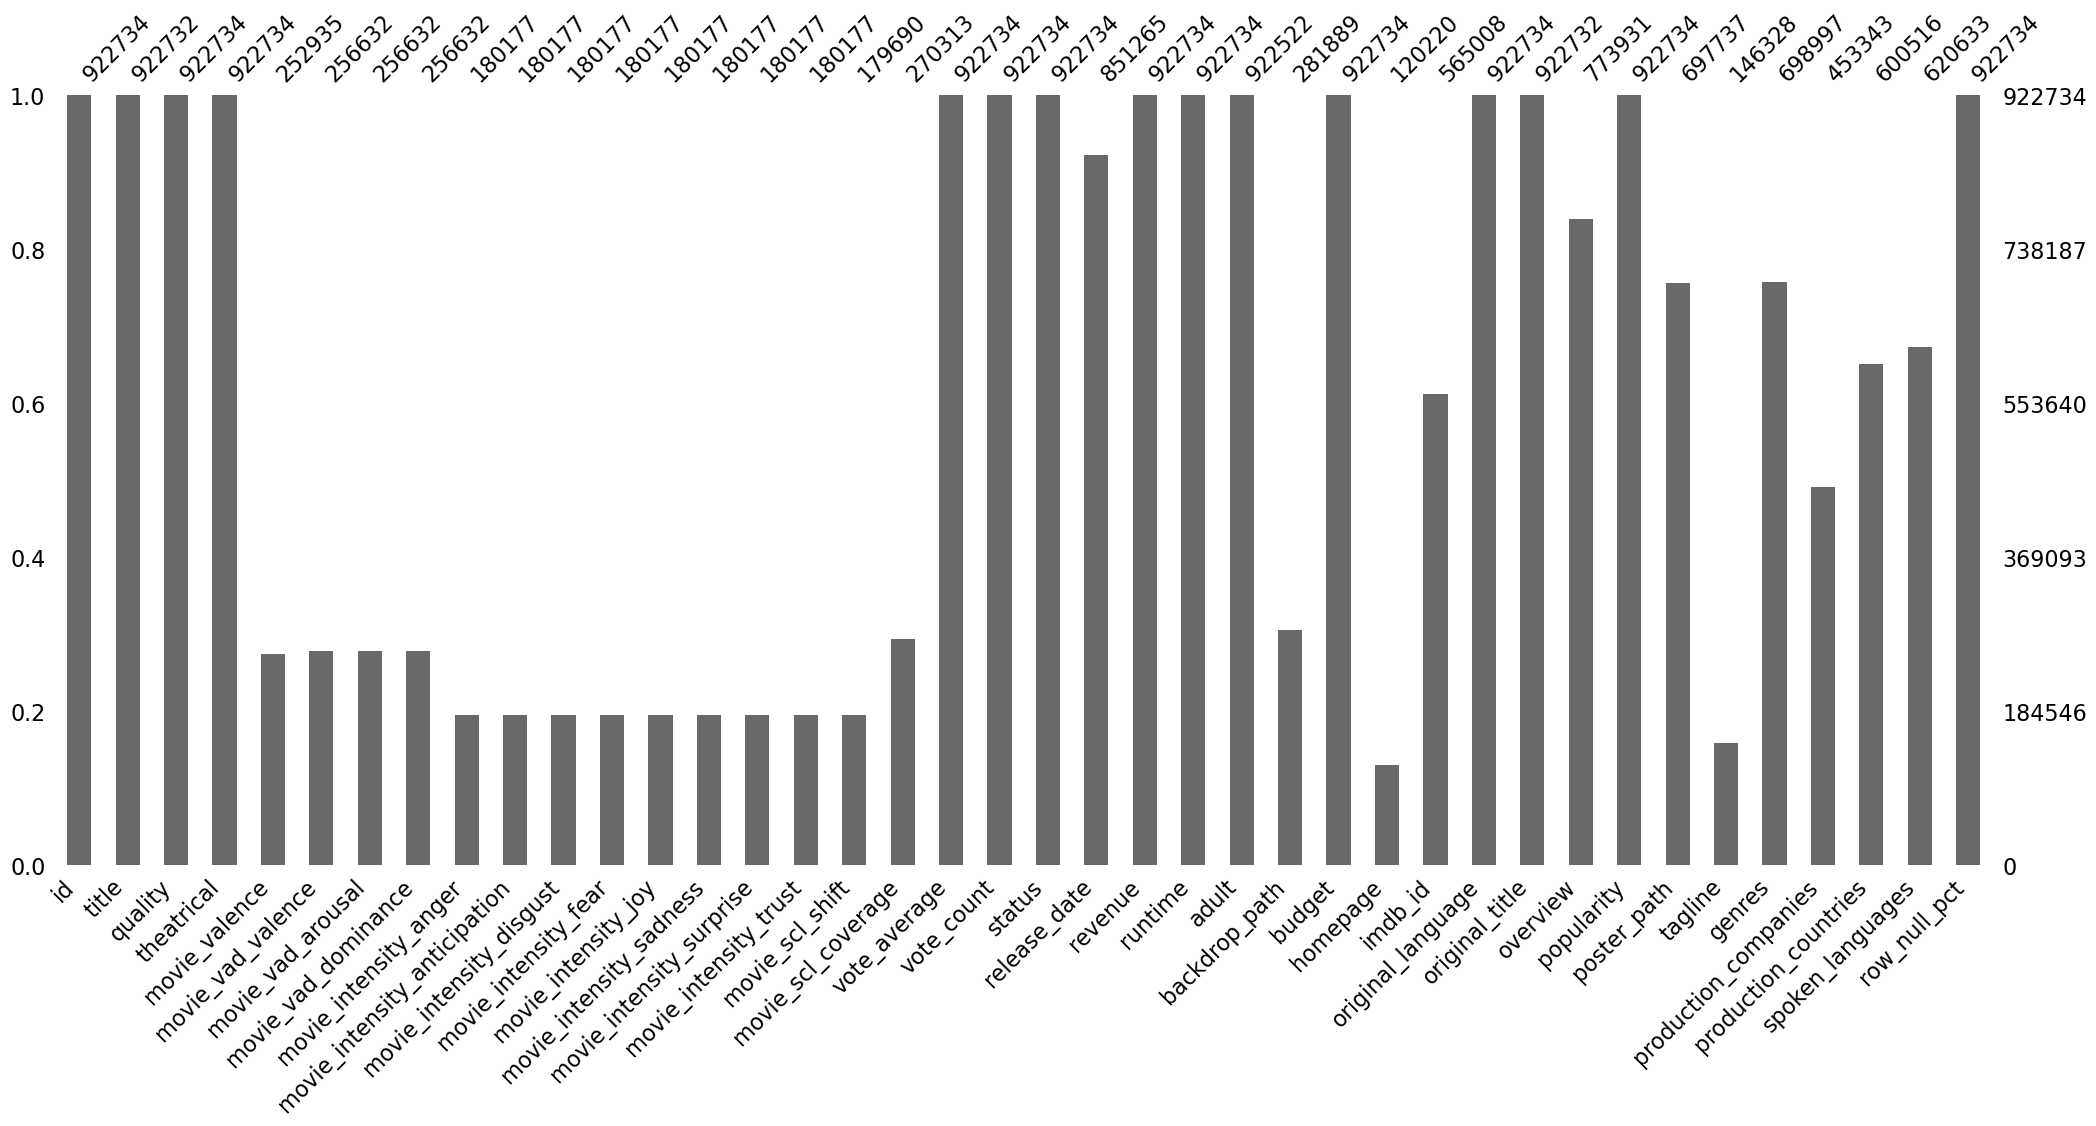

In [101]:
import missingno
missingno.bar(df)
plt.show()

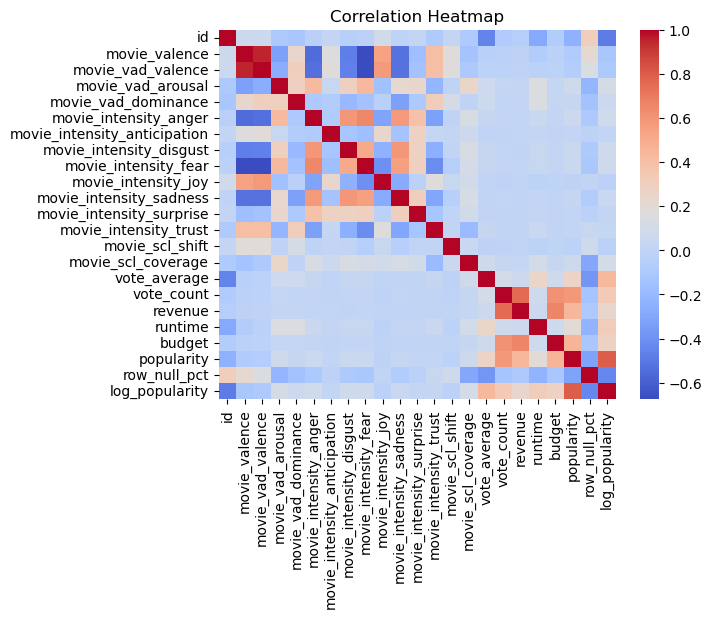

In [102]:
df['log_popularity'] = np.log1p(df['popularity'])
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()
plt.title("Correlation Heatmap")
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [103]:
corr_target = corr['log_popularity'].sort_values(ascending=False)
print(corr_target)

log_popularity                  1.000000
popularity                      0.798065
vote_average                    0.433077
vote_count                      0.337202
runtime                         0.310505
budget                          0.285092
revenue                         0.238404
movie_vad_arousal               0.111786
movie_scl_coverage              0.099545
movie_intensity_anger           0.078920
movie_intensity_fear            0.075918
movie_intensity_disgust         0.071502
movie_vad_dominance             0.055119
movie_intensity_sadness         0.038771
movie_intensity_trust           0.022960
movie_intensity_surprise        0.013118
movie_intensity_anticipation    0.005746
movie_intensity_joy            -0.030838
movie_scl_shift                -0.033287
movie_vad_valence              -0.094289
movie_valence                  -0.121972
row_null_pct                   -0.443754
id                             -0.487647
Name: log_popularity, dtype: float64


In [104]:
#correlation is v low for the intensity columns + valence/vad columns , and they have 80% nulls , will drop

In [105]:
emotion_cols = ['movie_intensity_anger', 'movie_intensity_disgust','movie_intensity_joy', 'movie_intensity_sadness','movie_intensity_trust', 'movie_intensity_fear','movie_intensity_surprise', 'movie_intensity_anticipation','movie_vad_valence', 'movie_vad_arousal', 'movie_vad_dominance','movie_valence', 'movie_scl_shift', 'movie_scl_coverage']

df.drop(columns=emotion_cols, inplace=True)

In [106]:
df.duplicated().sum()

120

In [107]:
df.drop(columns=['id'],inplace=True)

In [108]:
df.drop_duplicates(inplace=True)

In [109]:
df.duplicated().sum()

0

In [110]:
df.head()

,title,quality,theatrical,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,row_null_pct,log_popularity
266,Jaane Jaan,real_confident,True,7.125,36,Released,2023-09-21,0,139,False,/2vLhatnKrAXGOesLth1lhz76JTg.jpg,0,https://www.netflix.com/title/81586376,tt15748830,hi,जाने जां,When a single mother her teenage daughter becomes ensnar...,99.944,/oaUOV9VCNM5MjrmonqgH4o3XNwQ.jpg,NaN,"Crime, Thriller","Kross Pictures, Northern Lights Films, 12th Street Enter...","India, South Korea, United States of America","English, Hindi",0.071429,4.614566
267,Erotic Ghost Story,real_confident,True,6.287,54,Released,1990-05-19,0,88,False,/fpaVxLcSQnnMdtcCRdZV0eTjJPg.jpg,0,NaN,tt0100014,cn,聊齋艷譚,"Three vixens have meditated for 1,000 years to able to s...",99.535,/fTUCwsxVoLFuodAtlL6aITP1B45.jpg,NaN,"Fantasy, Drama, Horror","Diagonal Pictures, Orange Sky Golden Harvest",Hong Kong,Cantonese,0.571429,4.610506
268,Marvel Studios Assembled: The Making of Secret Invasion,real_confident,True,4.000,6,Released,2023-09-20,0,48,False,/phHZMvFlj5A03gzp7bhmQl8BInz.jpg,0,https://www.disneyplus.com/movies/assembled-the-making-o...,tt28663209,en,Marvel Studios Assembled: The Making of Secret Invasion,"Through in-depth interviews with cast and crew, and excl...",99.360,/8YDNwj9gsAQlcHQALPtjJipoGx8.jpg,NaN,Documentary,Marvel Studios,United States of America,English,0.071429,4.608764
269,The Lord of the Rings: The Return of the King,real_confident,True,8.474,22334,Released,2003-12-01,1118888979,201,False,/2u7zbn8EudG6kLlBzUYqP8RyFU4.jpg,94000000,http://www.lordoftherings.net,tt0167260,en,The Lord of the Rings: The Return of the King,Aragorn is revealed as the heir to the ancient kings as ...,99.276,/rCzpDGLbOoPwLjy3OAm5NUPOTrC.jpg,The eye of the enemy is moving.,"Adventure, Fantasy, Action","New Line Cinema, WingNut Films, The Saul Zaentz Company","New Zealand, United States of America",English,0.000000,4.607926
270,Remember,real_confident,True,7.426,54,Released,2022-10-26,0,128,False,/ru2LECaGqWtsL3kRWWJ3EoDlF5J.jpg,0,NaN,tt21279122,ko,리멤버,"Pil-ju, an Alzheimer's patient in his 80s, who lost all ...",99.267,/8y9mhh3PqGPXbZVhX7Mc25OJpHP.jpg,This revenge must be completed,"Thriller, Action, Drama","Moonlight Film, Acemaker Movieworks",South Korea,"Korean, Japanese",0.035714,4.607837


### Text Handling  

In [113]:
text_cols = {
    'overview': df.get('overview', pd.Series('')),
    'tagline' : df.get('tagline',  pd.Series('')),
}


In [114]:
df['text_combined'] = (
    df.get('overview', pd.Series('')).fillna('') + ' ' +
    df.get('tagline',  pd.Series('')).fillna('') + ' '
).str.strip()

In [115]:
df['text_combined'] = df['text_combined'].replace('', 'no description')


### Title

In [116]:
df.columns

Index(['title', 'quality', 'theatrical', 'vote_average', 'vote_count',
       'status', 'release_date', 'revenue', 'runtime', 'adult',
       'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path', 'tagline',
       'genres', 'production_companies', 'production_countries',
       'spoken_languages', 'row_null_pct', 'log_popularity', 'text_combined'],
      dtype='object')

In [117]:
df.loc[df['title']!=df['original_title'],['title','original_title']]

,title,original_title
266,Jaane Jaan,जाने जां
267,Erotic Ghost Story,聊齋艷譚
270,Remember,리멤버
272,Taste 2,맛 2
280,Mira,Мира
...,...,...
1048544,Three Museums on the Shore,Три музея на берегу
1048556,Things We Get Used To,익숙해지는 것들에 대하여
1048559,I Do Not Love My Future; I Love Guan Yin,我不爱前程爱观音
1048565,Riaru Kimo-dameshi,リアル肝試し


In [118]:
df[['title','original_title']].isnull().sum()

title             2
original_title    2
dtype: int64

In [119]:
df['title'].nunique()

786609

In [120]:
df.drop(columns=['title', 'original_title'], inplace=True)

### Theatrical

In [121]:
df['theatrical'].isnull().sum()

0

In [122]:
df['theatrical'].value_counts(normalize=True)

theatrical
True     0.95405
False    0.04595
Name: proportion, dtype: float64

In [123]:
df['theatrical'] = df['theatrical'].astype(int)

In [124]:
df['theatrical'].value_counts(normalize=True)

theatrical
1    0.95405
0    0.04595
Name: proportion, dtype: float64

### Vote_avg & vote_count

In [125]:
df['vote_average'].describe()

count    922605.000000
mean          2.110844
std           3.095669
min           0.000000
25%           0.000000
50%           0.000000
75%           5.000000
max          10.000000
Name: vote_average, dtype: float64

In [126]:
skew(df['vote_average'])

1.0147805824527196

In [127]:
# not skewed

In [128]:
df['vote_average'].isnull().sum()

0

In [129]:
df['vote_count'].describe()

count    922605.000000
mean         22.391798
std         336.886928
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       34495.000000
Name: vote_count, dtype: float64

In [130]:
skew(df['vote_count'])

36.43064267300144

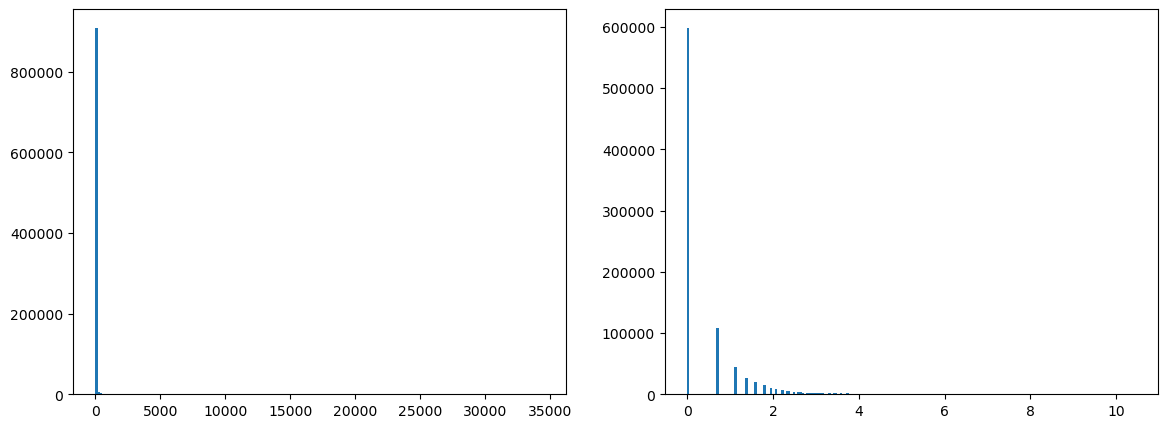

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['vote_count'], bins=200)
axes[1].hist(np.log1p(df['vote_count']), bins=200)

plt.show()

In [132]:
df['vote_count_log'] = np.log1p(df['vote_count'])

In [133]:
df['vote_count_log'].isnull().sum()

0

In [134]:
df.drop(columns=['vote_count'],inplace=True)

### Adult

In [135]:
df['adult'].isnull().sum()

212

In [136]:
df['adult'].value_counts()

adult
False    921857
True        536
Name: count, dtype: int64

In [137]:
## no variation almost 99.9% is False, will ad no significant info only noise, drop

In [138]:
df.drop(columns=['adult'],inplace=True)

### homepage

In [139]:
df['homepage'].head()

266                         https://www.netflix.com/title/81586376
267                                                            NaN
268    https://www.disneyplus.com/movies/assembled-the-making-o...
269                                  http://www.lordoftherings.net
270                                                            NaN
Name: homepage, dtype: object

In [140]:
df['homepage'].isnull().sum()

802409

In [141]:
df.drop(columns=['homepage'],inplace=True)

In [142]:
df.drop(columns=['imdb_id'],inplace=True)

### Original Language


In [143]:
from collections import Counter

In [144]:
freq=Counter(df['original_language'].values)

In [145]:
df['original_language'].isnull().sum()

0

In [146]:
freq.most_common(5)

[('en', 459956), ('fr', 58471), ('es', 52556), ('de', 44761), ('ja', 42327)]

In [147]:
df['original_language'].value_counts()

original_language
en    459956
fr     58471
es     52556
de     44761
ja     42327
       ...  
os         1
kj         1
kv         1
aa         1
ee         1
Name: count, Length: 173, dtype: int64

In [148]:
top_langs = df['original_language'].value_counts().nlargest(5).index

df['original_language'] = df['original_language'].apply(lambda x: x if x in top_langs else 'other')
df = pd.get_dummies(df, columns=['original_language'], prefix='lang')

### backdrop path

In [149]:
df['backdrop_path'].head()

266    /2vLhatnKrAXGOesLth1lhz76JTg.jpg
267    /fpaVxLcSQnnMdtcCRdZV0eTjJPg.jpg
268    /phHZMvFlj5A03gzp7bhmQl8BInz.jpg
269    /2u7zbn8EudG6kLlBzUYqP8RyFU4.jpg
270    /ru2LECaGqWtsL3kRWWJ3EoDlF5J.jpg
Name: backdrop_path, dtype: object

In [150]:
df.drop(columns=['backdrop_path'],inplace=True)

### Status

In [151]:
df['status'].isnull().sum()

0

In [152]:
df['status'].value_counts()

status
Released           889205
In Production       15678
Post Production     10056
Planned              7227
Rumored               286
Canceled              153
Name: count, dtype: int64

In [153]:
#split

In [154]:
df['is_released'] = (df['status'] == 'Released').astype(int)

df['is_in_pipeline'] = df['status'].isin(
    ['In Production','Post Production','Planned']).astype(int)

df['is_uncertain'] = (df['status']=='Rumored').astype(int)

df['is_canceled'] = (df['status'] == 'Canceled').astype(int)

In [155]:
df.drop(columns=['status'],inplace=True)

### Production Companies

In [156]:
df['production_companies'].value_counts()

production_companies
ONF | NFB                                                 2327
BBC                                                       2106
Metro-Goldwyn-Mayer                                       2031
Columbia Pictures                                         1941
Toei Company                                              1789
                                                          ... 
BOB Film Sweden, SF Studios                                  1
Unité Un                                                     1
PIP, Prima Film                                              1
The IdeaFirst Company, Sine Caboloan, HYDEntertainment       1
Streaming Musicals                                           1
Name: count, Length: 212529, dtype: int64

In [157]:
df['production_companies_list'] = df['production_companies'].fillna('').apply(
    lambda x: [c.strip() for c in x.split(',')] if x != '' else []
)

In [158]:
from itertools import chain

In [159]:
all_companies = list(chain.from_iterable(df['production_companies_list']))
company_counts = pd.Series(all_companies).value_counts()
print(company_counts.head(30))


Warner Bros. Pictures            3207
BBC                              3096
Columbia Pictures                2924
Metro-Goldwyn-Mayer              2852
ARTE                             2793
ONF | NFB                        2753
Universal Pictures               2672
Paramount                        2585
ZDF                              2329
Toei Company                     2257
Nikkatsu Corporation             1861
20th Century Fox                 1703
ARD                              1534
Mosfilm                          1528
Canal+                           1515
TOHO                             1408
Shochiku                         1367
Česká televize                   1340
France Télévisions               1236
RKO Radio Pictures               1192
CNC                              1106
Walt Disney Productions          1104
SVT                              1096
RAI                              1058
DEFA                             1037
WDR                               972
Filmové stud

In [160]:
top_companies = company_counts.head(25).index.tolist()
print(top_companies)

df['no_of_large_production_companies'] = df['production_companies_list'].apply(
    lambda companies: int(sum(c in top_companies for c in companies))
)


['Warner Bros. Pictures', 'BBC', 'Columbia Pictures', 'Metro-Goldwyn-Mayer', 'ARTE', 'ONF | NFB', 'Universal Pictures', 'Paramount', 'ZDF', 'Toei Company', 'Nikkatsu Corporation', '20th Century Fox', 'ARD', 'Mosfilm', 'Canal+', 'TOHO', 'Shochiku', 'Česká televize', 'France Télévisions', 'RKO Radio Pictures', 'CNC', 'Walt Disney Productions', 'SVT', 'RAI', 'DEFA']


In [161]:
df.isnull().sum()

quality                                  0
theatrical                               0
vote_average                             0
release_date                         71438
revenue                                  0
runtime                                  0
budget                                   0
overview                            148775
popularity                               0
poster_path                         224961
tagline                             776304
genres                              223699
production_companies                469318
production_countries                322145
spoken_languages                    302038
row_null_pct                             0
log_popularity                           0
text_combined                            0
vote_count_log                           0
lang_de                                  0
lang_en                                  0
lang_es                                  0
lang_fr                                  0
lang_ja    

In [162]:
df['num_production_companies'] = df['production_companies_list'].apply(len)

In [163]:
df.drop(columns=['production_companies','production_companies_list'], inplace=True)

### poster path +tagline

In [164]:
df['poster_path'].head()

266    /oaUOV9VCNM5MjrmonqgH4o3XNwQ.jpg
267    /fTUCwsxVoLFuodAtlL6aITP1B45.jpg
268    /8YDNwj9gsAQlcHQALPtjJipoGx8.jpg
269    /rCzpDGLbOoPwLjy3OAm5NUPOTrC.jpg
270    /8y9mhh3PqGPXbZVhX7Mc25OJpHP.jpg
Name: poster_path, dtype: object

In [165]:
df.drop(columns=['poster_path'], inplace=True)

In [166]:
df['tagline'].isnull().sum()*100/len(df)

84.14261791340823

In [167]:
# 85% is null , and similar to overview which was handled in detail

In [168]:
df.drop(columns='tagline', inplace=True)

### Quality

In [169]:
df['quality'].value_counts(normalize=True)

quality
stub_uncertain     0.354152
real_likely        0.344186
stub_legitimate    0.181027
real_confident     0.117384
spam_confident     0.002058
spam_likely        0.001193
Name: proportion, dtype: float64

In [170]:
df['quality'].unique()

array(['real_confident', 'real_likely', 'stub_legitimate',
       'stub_uncertain', 'spam_likely', 'spam_confident'], dtype=object)

In [171]:
df['quality'].isnull().sum()

0

In [172]:
df['quality_type'] = df['quality'].str.split('_').str[0]

In [173]:
df['quality_type'].value_counts()

quality_type
stub    493758
real    425847
spam      3000
Name: count, dtype: int64

In [174]:
df['quality_confidence'] = df['quality'].str.split('_').str[1]

In [175]:
df['quality_confidence'].value_counts()

quality_confidence
uncertain     326742
likely        318649
legitimate    167016
confident     110198
Name: count, dtype: int64

In [176]:
quality_map={'spam':-1, 'stub':0, 'real':1}
df['quality_type']=df['quality_type'].map(quality_map)

In [177]:
confidence_map = {'confident': 3,'legitimate': 2,'likely': 1,'uncertain': 0
}

df['quality_confidence'] = df['quality_confidence'].map(confidence_map)

In [178]:
df['quality_confidence'].value_counts()

quality_confidence
0    326742
1    318649
2    167016
3    110198
Name: count, dtype: int64

In [179]:
df['quality_type'] = df['quality_type'].map(quality_map).fillna(0)
df['quality_confidence'] = df['quality_confidence'].map(confidence_map).fillna(0)


In [180]:
df.drop(columns=['quality_type'],inplace=True)

In [181]:
df.drop(columns=['quality'],inplace=True)

### overview

In [182]:
df['overview'].isnull().sum()/len(df)

0.16125535846868377

In [183]:
df['overview'].head()

266    When a single mother her teenage daughter becomes ensnar...
267    Three vixens have meditated for 1,000 years to able to s...
268    Through in-depth interviews with cast and crew, and excl...
269    Aragorn is revealed as the heir to the ancient kings as ...
270    Pil-ju, an Alzheimer's patient in his 80s, who lost all ...
Name: overview, dtype: object

In [184]:
df['overview'] = df['overview'].fillna('').astype(str)

print("Empty strings:", (df['overview'].str.strip() == '').sum())

Empty strings: 149560


In [185]:
df['overview'].isnull().sum()

0

In [186]:
df['overview'] = df['overview'].replace('', None)

In [187]:
df['overview'].isnull().sum()

148775

In [188]:
df['overview'].fillna('no overview', inplace=True)

In [189]:
##pip install sentence-transformers

In [190]:
#from sentence_transformers import SentenceTransformer

#model = SentenceTransformer('all-MiniLM-L6-v2')

In [191]:
#chunk_size = 50_000
#batch_size = 32

#all_files = []

In [192]:
#texts = df['overview'].fillna('').astype(str).tolist()

In [193]:
#len(texts)

In [194]:
#for i in range(0, len(texts), chunk_size):
 #   batch_texts = texts[i:i+chunk_size]

  #  embeddings = model.encode(batch_texts,batch_size=batch_size,convert_to_numpy=True,show_progress_bar=True)

   # embeddings = embeddings.astype('float32')

    #file_name = f"embeddings_{i}.npy"
    #np.save(file_name, embeddings)

   # print(f"Saved: {file_name}")

In [195]:
df['overview'].isnull().sum()

0

In [196]:
df['overview'].str.contains('no overview', case=False).astype(int).sum()

148837

In [197]:
no_overview_mask = df['overview'].str.strip().str.lower() == 'no overview'

In [198]:
df['has_overview'] = (~no_overview_mask).astype(int)

In [199]:
df['overview_len'] = df['overview'].str.len().fillna(0)
df['word_count'] = df['overview'].str.split().str.len().fillna(0)

In [200]:
df['has_based_on']= df['overview'].str.contains(r'based on', case=False, na=False).astype(int)
df['has_true_story']= df['overview'].str.contains(r'true story', case=False, na=False).astype(int)
df['has_sequel_hint'] = df['overview'].str.contains(r'\bsequel\b|\bpart \d\b|\bchapter \d\b', case=False, na=False).astype(int)


In [201]:
df['theme_action']= df['overview'].str.contains(r'war|battle|fight|mission|agent|weapon', case=False, na=False).astype(int)
df['theme_romance']= df['overview'].str.contains(r'love|romance|relationship|heart', case=False, na=False).astype(int)
df['theme_horror']= df['overview'].str.contains(r'terror|haunted|demon|evil|supernatural|fear', case=False, na=False).astype(int)
df['theme_family']= df['overview'].str.contains(r'family|daughter|son|father|mother|child', case=False, na=False).astype(int)
df['theme_scifi']= df['overview'].str.contains(r'alien|space|future|robot|galaxy|planet', case=False, na=False).astype(int)


In [202]:
df.loc[no_overview_mask, 'overview_len'] = 0
df.loc[no_overview_mask, 'word_count'] = 0
df.loc[no_overview_mask, 'avg_word_length'] = 0
df.loc[no_overview_mask, ['sentiment_pos', 'sentiment_neg', 'sentiment_compound']] = 0
df.loc[no_overview_mask, ['has_based_on', 'has_true_story', 'has_sequel_hint']] = 0
df.loc[no_overview_mask, ['theme_action', 'theme_romance', 'theme_horror', 'theme_family', 'theme_scifi']] = 0

In [203]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sid = SentimentIntensityAnalyzer()

mask = df['overview'].notna()
scores = df.loc[~no_overview_mask, 'overview'].apply(lambda x: sid.polarity_scores(x))
df.loc[~no_overview_mask, 'sentiment_pos'] = scores.apply(lambda x: x['pos'])
df.loc[~no_overview_mask, 'sentiment_neg'] = scores.apply(lambda x: x['neg'])
df.loc[~no_overview_mask, 'sentiment_compound'] = scores.apply(lambda x: x['compound'])
df[['sentiment_pos','sentiment_neg','sentiment_compound']] = df[['sentiment_pos','sentiment_neg','sentiment_compound']].fillna(0)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


In [204]:
overview_text = df['overview'].copy()

In [205]:
df.drop(columns=['overview'],inplace=True)

In [206]:
df.drop(columns=['avg_word_length'],inplace=True)

### Train Test Split

In [208]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['popularity', 'log_popularity', 'row_null_pct'], errors='ignore')
y = df['log_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Embeddings

In [209]:
# train_texts = df.loc[X_train.index, 'text_combined'].tolist()
# test_texts  = df.loc[X_test.index,  'text_combined'].tolist()

In [210]:
df.drop(columns=['text_combined'], inplace=True)

In [211]:
# st_model = SentenceTransformer('all-MiniLM-L6-v2')

In [212]:
# emb_train = st_model.encode(
#     train_texts,
#     batch_size=512,
#     convert_to_numpy=True,
#     normalize_embeddings=True,
#     show_progress_bar=True
# ).astype('float16')         # bn quatize aashan el ram


In [213]:
# emb_test = st_model.encode(
#     test_texts,
#     batch_size=512,
#     convert_to_numpy=True,
#     normalize_embeddings=True,
#     show_progress_bar=True
# ).astype('float16')

In [214]:
# del st_model

In [215]:
#sample_idx = np.random.choice(len(emb_train), size=100_000, replace=False)

# cumvar = np.cumsum(pca.explained_variance_ratio_)
# print("For 80%:", np.argmax(cumvar >= 0.80) + 1)
# print("For 90%:", np.argmax(cumvar >= 0.90) + 1)

# import matplotlib.pyplot as plt
# plt.plot(cumvar)
# plt.axhline(0.80, color='red',    linestyle='--', label='80%')
# plt.axhline(0.90, color='orange', linestyle='--', label='90%')
# plt.xlabel('n_components')
# plt.ylabel('Cumulative explained variance')
# plt.legend()
# plt.show()

# n = np.argmax(cumvar >= 0.80) + 1
# print(f"Refitting PCA with n_components={n}")
# pca = PCA(n_components=n, random_state=42)
# pca.fit(emb_train[sample_idx].astype('float32'))

In [216]:
# n = 121  # 80% explained variance
# pca = PCA(n_components=n, random_state=42)
# pca.fit(emb_train[sample_idx].astype('float32'))


In [217]:
# print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

In [218]:
# def pca_transform_chunked(emb, pca, chunk_size=50_000):
#     n_components = pca.n_components_
#     out = np.zeros((len(emb), n_components), dtype='float16')
#     for i in range(0, len(emb), chunk_size):
#         chunk = emb[i:i+chunk_size].astype('float32')  # upcast per chunk only
#         out[i:i+chunk_size] = pca.transform(chunk).astype('float16')
#     return out

In [219]:
# emb_train_pca = pca_transform_chunked(emb_train, pca)
# del emb_train

In [220]:
# emb_test_pca = pca_transform_chunked(emb_test, pca)
# del emb_test

In [221]:
# emb_train_f32 = emb_train_pca.astype('float32')
# emb_test_f32  = emb_test_pca.astype('float32')   # quantization
# del emb_train_pca, emb_test_pca

In [222]:
# del emb_train_f32 , emb_test_f32 , pca

In [223]:
X_train.drop(columns=['text_combined'], inplace=True)
X_test.drop(columns=['text_combined'], inplace=True)

### TF-IDF + PCA

In [225]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import PCA

# overview_train = overview_text.loc[X_train.index].fillna('no overview').astype(str)
# overview_test  = overview_text.loc[X_test.index].fillna('no overview').astype(str)

# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     max_features=400,
#     stop_words='english',
#     min_df=10,
#     max_df=0.85,
#     sublinear_tf=True,
#     ngram_range=(1, 2),
# )

# tfidf_train = tfidf.fit_transform(overview_train)
# tfidf_test  = tfidf.transform(overview_test)

# print(f"TF-IDF matrix shape: {tfidf_train.shape}")
# print(f"Actual vocabulary size: {len(tfidf.vocabulary_)}")

# from sklearn.decomposition import TruncatedSVD
# import numpy as np

# svd_probe = TruncatedSVD(n_components=100, random_state=42)
# svd_probe.fit(tfidf_train)

# cumvar = np.cumsum(svd_probe.explained_variance_ratio_)

# plt.figure(figsize=(9, 3))
# plt.plot(cumvar, linewidth=2)
# plt.axhline(0.70, color='green',  linestyle='--', label=f'70% → {np.searchsorted(cumvar, 0.70)+1} components')
# plt.axhline(0.75, color='orange', linestyle='--', label=f'75% → {np.searchsorted(cumvar, 0.75)+1} components')
# plt.axhline(0.80, color='red',    linestyle='--', label=f'80% → {np.searchsorted(cumvar, 0.80)+1} components')
# plt.xlabel('Components'); plt.ylabel('Cumulative variance')
# plt.title('TF-IDF SVD — Variance Curve')
# plt.legend(); plt.tight_layout(); plt.show()

# for t in [0.70, 0.75, 0.80]:
#     n = int(np.searchsorted(cumvar, t)) + 1
#     print(f"  {t:.0%} variance → {n} components")

# N_COMPONENTS = int(np.searchsorted(cumvar, 0.75)) + 1
# print(f"\nUsing {N_COMPONENTS} components")

# svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
# pca_train = svd.fit_transform(tfidf_train)
# pca_test  = svd.transform(tfidf_test)

# print(f"Final explained variance: {svd.explained_variance_ratio_.sum():.2%}")

# pca_cols = [f'overview_pca_{i}' for i in range(N_COMPONENTS)]

# X_train_text = pca_train
# X_test_text  = pca_test
# print(f"X_train shape: {X_train.shape}")
# print(f"X_test  shape: {X_test.shape}")

### release_date

In [226]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [227]:
X_train['release_date'] = pd.to_datetime(X_train['release_date'], errors='coerce')
X_train['release_date_missing'] = X_train['release_date'].isna().astype(int)
X_train['release_year']  = X_train['release_date'].dt.year
X_train['release_month'] = X_train['release_date'].dt.month
X_train.drop(columns=['release_date'], inplace=True)
X_train['budget']  = X_train['budget'].replace(0, np.nan)
X_train['revenue'] = X_train['revenue'].replace(0, np.nan)

In [228]:
X_test['release_date'] = pd.to_datetime(X_test['release_date'], errors='coerce')
X_test['release_date_missing'] = X_test['release_date'].isna().astype(int)
X_test['release_year']  = X_test['release_date'].dt.year
X_test['release_month'] = X_test['release_date'].dt.month
X_test.drop(columns=['release_date'], inplace=True)
X_test['budget']  = X_test['budget'].replace(0, np.nan)
X_test['revenue'] = X_test['revenue'].replace(0, np.nan)

In [229]:
mice_features = ['release_year', 'release_month', 'revenue', 'budget', 'vote_average', 'vote_count_log', 'runtime', 'theatrical']
imputer = IterativeImputer(max_iter=10, random_state=42)

In [230]:
released_mask_train = X_train['is_released'] == 1
imputer.fit(X_train.loc[released_mask_train, mice_features])

IterativeImputer(random_state=42)

In [231]:
X_train.loc[released_mask_train, mice_features] = imputer.transform(X_train.loc[released_mask_train, mice_features])
X_train['release_year']  = X_train['release_year'].round().clip(1880, 2026)
X_train['release_month'] = X_train['release_month'].round().clip(1, 12)

In [232]:
released_mask_test = X_test['is_released'] == 1
X_test.loc[released_mask_test, mice_features] = imputer.transform(X_test.loc[released_mask_test, mice_features])
X_test['release_year']  = X_test['release_year'].round().clip(1880, 2026)
X_test['release_month'] = X_test['release_month'].round().clip(1, 12)

In [233]:
not_released_mask_train = X_train['is_released'] == 0
X_train.loc[not_released_mask_train & X_train['release_year'].isna(), 'release_year'] = -1
X_train.loc[not_released_mask_train & X_train['release_month'].isna(), 'release_month'] = -1

In [234]:
not_released_mask_test = X_test['is_released'] == 0
X_test.loc[not_released_mask_test & X_test['release_year'].isna(), 'release_year'] = -1
X_test.loc[not_released_mask_test & X_test['release_month'].isna(), 'release_month'] = -1

In [235]:
def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    elif month in [9, 10, 11]:
        return 4
    else:
        return -1

In [236]:
X_train['release_season'] = X_train['release_month'].apply(get_season)
X_test['release_season']  = X_test['release_month'].apply(get_season)


In [237]:
X_train['release_decade'] = X_train.apply(
    lambda row: (int(row['release_year'] // 10) * 10) if row['release_date_missing'] == 0 else np.nan, axis=1
)

In [238]:
X_train['decade_unknown'] = X_train['release_decade'].isna().astype(int)
X_train['release_decade'] = X_train['release_decade'].fillna(-1)

In [239]:
X_test['release_decade'] = X_test.apply(
    lambda row: (int(row['release_year'] // 10) * 10) if row['release_date_missing'] == 0 else np.nan, axis=1
)
X_test['decade_unknown'] = X_test['release_decade'].isna().astype(int)
X_test['release_decade'] = X_test['release_decade'].fillna(-1)

In [240]:
X_train['movie_age'] = np.where(X_train['release_date_missing'] == 0, 2026 - X_train['release_year'], np.nan)
X_test['movie_age']  = np.where(X_test['release_date_missing'] == 0, 2026 - X_test['release_year'], np.nan)

In [241]:
train_age_median = X_train['movie_age'].median()
X_train['movie_age'] = X_train['movie_age'].fillna(train_age_median)
X_test['movie_age']  = X_test['movie_age'].fillna(train_age_median)

### Production Countries

In [242]:
X_train['production_countries_list'] = X_train['production_countries'].fillna('').apply(
    lambda x: [c.strip() for c in x.split(',')] if x != '' else []
)
X_test['production_countries_list'] = X_test['production_countries'].fillna('').apply(
    lambda x: [c.strip() for c in x.split(',')] if x != '' else []
)

In [243]:
from collections import Counter
from itertools import chain

In [244]:
all_countries_train = list(chain.from_iterable(X_train['production_countries_list']))
country_counts = pd.Series(all_countries_train).value_counts()
top5_countries = country_counts.head(5).index.tolist()

In [245]:
def map_countries(countries):
    mapped = [c if c in top5_countries else 'other' for c in countries]
    return list(set(mapped))

In [246]:
X_train['production_countries_mapped'] = X_train['production_countries_list'].apply(map_countries)
X_train['production_countries_mapped'] = X_train['production_countries_mapped'].apply(lambda x: x if x else ['other'])

In [247]:
X_test['production_countries_mapped'] = X_test['production_countries_list'].apply(map_countries)
X_test['production_countries_mapped'] = X_test['production_countries_mapped'].apply(lambda x: x if x else ['other'])

In [248]:
from sklearn.preprocessing import MultiLabelBinarizer

In [249]:
mlb_countries = MultiLabelBinarizer()
countries_matrix_train = mlb_countries.fit_transform(X_train['production_countries_mapped'])
countries_matrix_test = mlb_countries.transform(X_test['production_countries_mapped'])



In [250]:
countries_df_train = pd.DataFrame(countries_matrix_train, columns=mlb_countries.classes_, index=X_train.index)
countries_df_test = pd.DataFrame(countries_matrix_test, columns=mlb_countries.classes_, index=X_test.index)
X_train = pd.concat([X_train, countries_df_train], axis=1)
X_test = pd.concat([X_test, countries_df_test], axis=1)

In [251]:
cols_to_drop = ['production_countries', 'production_countries_list', 'production_countries_mapped']

X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

### runtime

207593
621
207593
621
runtime                             1.000000
vote_count_log                      0.313109
log_popularity                      0.310516
has_overview                        0.267810
word_count                          0.256470
overview_len                        0.256396
vote_average                        0.248897
popularity                          0.195710
num_production_companies            0.185915
theme_family                        0.145116
sentiment_pos                       0.136856
sentiment_neg                       0.123469
theme_romance                       0.113558
theme_action                        0.102557
is_released                         0.095668
no_of_large_production_companies    0.076049
budget                              0.067003
revenue                             0.052667
theme_horror                        0.049258
has_based_on                        0.031096
has_true_story                      0.024375
theme_scifi                      

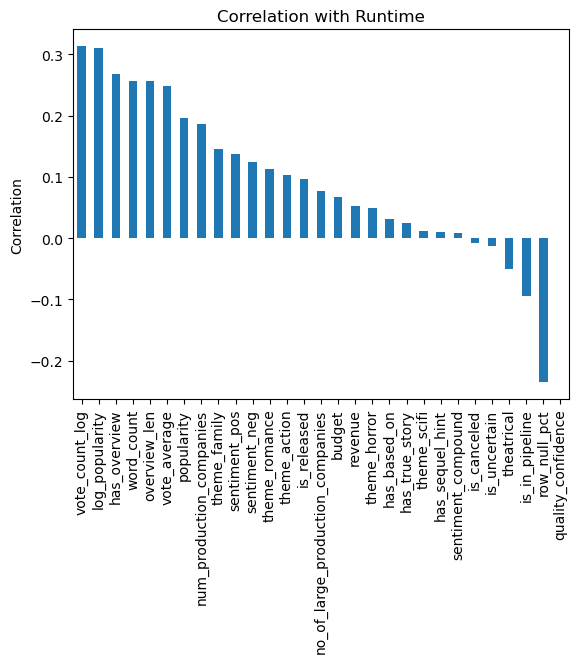

In [252]:
df['runtime'].describe()
df['runtime'].isnull().sum()
df['runtime'].dtype
print(df[df['runtime'] <= 0]['runtime'].count())
print(df[df['runtime'] > 400]['runtime'].count())
print(df[df['runtime'] <= 0]['runtime'].count())
print(df[df['runtime'] > 400]['runtime'].count())
numeric_df = df.select_dtypes(include=['number'])
corr_runtime = numeric_df.corr()['runtime'].sort_values(ascending=False)
print(corr_runtime)
import matplotlib.pyplot as plt
corr_runtime.drop('runtime').plot(kind='bar')
plt.title("Correlation with Runtime")
plt.ylabel("Correlation")
plt.show()

In [253]:
X_train['runtime'] = X_train['runtime'].where((X_train['runtime'] > 0) & (X_train['runtime'] <= 400), np.nan)
X_test['runtime'] = X_test['runtime'].where((X_test['runtime'] > 0) & (X_test['runtime'] <= 400), np.nan)

In [254]:
features = ['vote_count_log', 'quality_confidence', 'vote_average', 'is_released']

In [255]:
train_known = X_train[X_train['runtime'].notna()]
train_unknown = X_train[X_train['runtime'].isna()]

In [256]:
from sklearn.ensemble import RandomForestRegressor

In [257]:
model_runtime = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_runtime.fit(train_known[features], train_known['runtime'])

RandomForestRegressor(n_jobs=-1, random_state=42)

In [258]:
X_train.loc[X_train['runtime'].isna(), 'runtime'] = model_runtime.predict(train_unknown[features])

In [259]:
test_unknown = X_test[X_test['runtime'].isna()]
X_test.loc[X_test['runtime'].isna(), 'runtime'] = model_runtime.predict(test_unknown[features])

### Genres

In [260]:
X_train['all_genres'] = X_train['genres'].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
X_test['all_genres'] = X_test['genres'].apply(lambda x: x.split(', ') if isinstance(x, str) else [])

In [261]:
X_train['has_genres'] = X_train['genres'].notna().astype(int)
X_test['has_genres'] = X_test['genres'].notna().astype(int)

In [262]:
X_train['num_genres'] = X_train['all_genres'].apply(len)
X_test['num_genres'] = X_test['all_genres'].apply(len)

In [263]:
genre_groups = {
    'action_group': ['Action', 'Adventure', 'Thriller', 'War'],
    'comedy_group': ['Comedy', 'Family'],
    'drama_group': ['Drama', 'History'],
    'romance_group': ['Romance'],
    'sci_fi_group': ['Science Fiction', 'Fantasy'],
    'dark_group': ['Horror', 'Crime', 'Mystery'],
    'other_group': ['Documentary', 'Music', 'TV Movie', 'Western', 'Animation']
}

In [264]:
def map_to_groups(genres):
    if not isinstance(genres, list):
        genres = []
    groups = []
    for group_name, group_genres in genre_groups.items():
        if any(g in genres for g in group_genres):
            groups.append(group_name)
    return groups

In [265]:
X_train['genre_groups_list'] = X_train['all_genres'].apply(map_to_groups)
X_test['genre_groups_list'] = X_test['all_genres'].apply(map_to_groups)

In [266]:
def fill_missing_groups(row):
    if row['has_genres']:
        return row['genre_groups_list']
    inferred = []
    if row['theme_action']:
        inferred.append('action_group')
    if row['theme_romance']:
        inferred.append('romance_group')
    if row['theme_scifi']:
        inferred.append('sci_fi_group')
    if row['theme_horror']:
        inferred.append('dark_group')
    if row['theme_family']:
        inferred.append('comedy_group')
    return inferred

In [267]:
train_mask = X_train['genres'].isna()
test_mask = X_test['genres'].isna()

In [268]:
X_train.loc[train_mask, 'genre_groups_list'] = X_train.loc[train_mask].apply(fill_missing_groups, axis=1)
X_test.loc[test_mask, 'genre_groups_list'] = X_test.loc[test_mask].apply(fill_missing_groups, axis=1)

In [269]:
mlb_genres = MultiLabelBinarizer()
group_matrix_train = mlb_genres.fit_transform(X_train['genre_groups_list'])
group_matrix_test = mlb_genres.transform(X_test['genre_groups_list'])

In [270]:
group_df_train = pd.DataFrame(group_matrix_train, columns=mlb_genres.classes_, index=X_train.index)
group_df_test = pd.DataFrame(group_matrix_test, columns=mlb_genres.classes_, index=X_test.index)

In [271]:
X_train = pd.concat([X_train, group_df_train], axis=1)
X_test = pd.concat([X_test, group_df_test], axis=1)

In [272]:
X_train.drop(columns=['genres',  'spoken_languages'], inplace=True)
X_test.drop(columns=['genres',  'spoken_languages'], inplace=True)

In [273]:
cols_to_drop = ['all_genres', 'genre_groups_list']
X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

### Revenue & Budget

In [274]:
X_train['budget_known']  = (X_train['budget'] > 0).astype(int)
X_test['budget_known']   = (X_test['budget'] > 0).astype(int)

In [275]:
X_train['revenue_known'] = (X_train['revenue'] > 0).astype(int)
X_test['revenue_known']  = (X_test['revenue'] > 0).astype(int)

In [276]:
X_train['both_known'] = ((X_train['budget'] > 0) & (X_train['revenue'] > 0)).astype(int)
X_test['both_known']  = ((X_test['budget'] > 0) & (X_test['revenue'] > 0)).astype(int)

In [277]:
X_train['is_blockbuster'] = ((X_train['budget'] >= 20_000_000) & (X_train['revenue'] >= 50_000_000)).astype(int)
X_test['is_blockbuster']  = ((X_test['budget'] >= 20_000_000) & (X_test['revenue'] >= 50_000_000)).astype(int)

In [278]:
X_train['budget_log']  = np.log1p(X_train['budget'].fillna(0))
X_test['budget_log']   = np.log1p(X_test['budget'].fillna(0))

In [279]:
X_train['revenue_log'] = np.log1p(X_train['revenue'].fillna(0))
X_test['revenue_log']  = np.log1p(X_test['revenue'].fillna(0))

In [280]:
roi_mask_train = (X_train['budget'] > 0) & (X_train['revenue'] > 0)
roi_mask_test  = (X_test['budget'] > 0) & (X_test['revenue'] > 0)

In [281]:
X_train['roi'] = np.where(roi_mask_train, (X_train['revenue'] - X_train['budget']) / X_train['budget'], np.nan)
X_test['roi']  = np.where(roi_mask_test,  (X_test['revenue']  - X_test['budget'])  / X_test['budget'],  np.nan)

In [282]:
roi_median = X_train['roi'].median()
X_train['roi'] = X_train['roi'].fillna(roi_median)
X_test['roi']  = X_test['roi'].fillna(roi_median)

In [283]:
X_train.drop(columns=['budget', 'revenue'], inplace=True)
X_test.drop(columns=['budget', 'revenue'], inplace=True)

## Analysis on the features

In [284]:
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler


In [285]:
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (738084, 60), X_test: (184521, 60)


In [286]:
print(y_train.describe())

count    738084.000000
mean          0.634727
std           0.480315
min           0.000000
25%           0.470004
50%           0.470004
75%           0.710496
max           4.610506
Name: log_popularity, dtype: float64


Text(0.5, 1.0, 'y_train distribution')

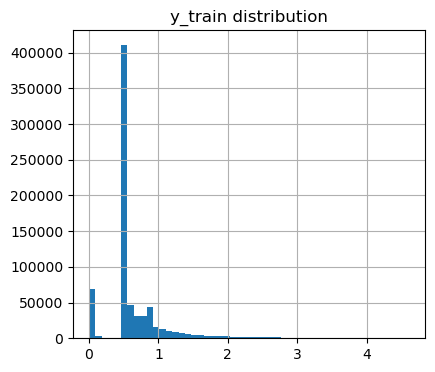

In [287]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
y_train.hist(bins=50)
plt.title("y_train distribution")

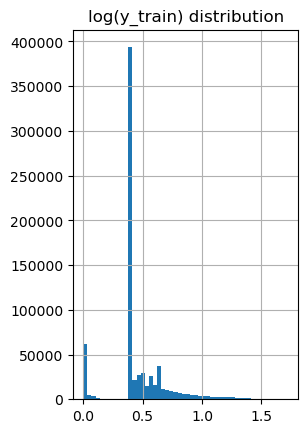

In [288]:
plt.subplot(1, 2, 2)
np.log1p(y_train).hist(bins=50)
plt.title("log(y_train) distribution")
plt.show()

In [289]:
missing = X_train.isnull().sum()
missing = missing[missing > 0]
print(missing if len(missing) > 0 else "No missing values")

revenue_log    29585
dtype: int64


In [290]:
numeric_cols = X_train.select_dtypes(include='number').columns
correlations = X_train[numeric_cols].corrwith(y_train).abs().sort_values(ascending=False)
print(correlations)

vote_count_log                      0.796287
vote_average                        0.433101
num_production_companies            0.401778
runtime                             0.358843
num_genres                          0.351746
is_blockbuster                      0.268453
United States of America            0.258388
action_group                        0.202895
has_genres                          0.202108
other                               0.195077
no_of_large_production_companies    0.186620
decade_unknown                      0.162491
release_date_missing                0.162491
release_decade                      0.161471
drama_group                         0.151726
has_overview                        0.139309
sentiment_neg                       0.134595
dark_group                          0.132778
word_count                          0.121393
overview_len                        0.114807
budget_log                          0.113916
comedy_group                        0.105920
romance_gr

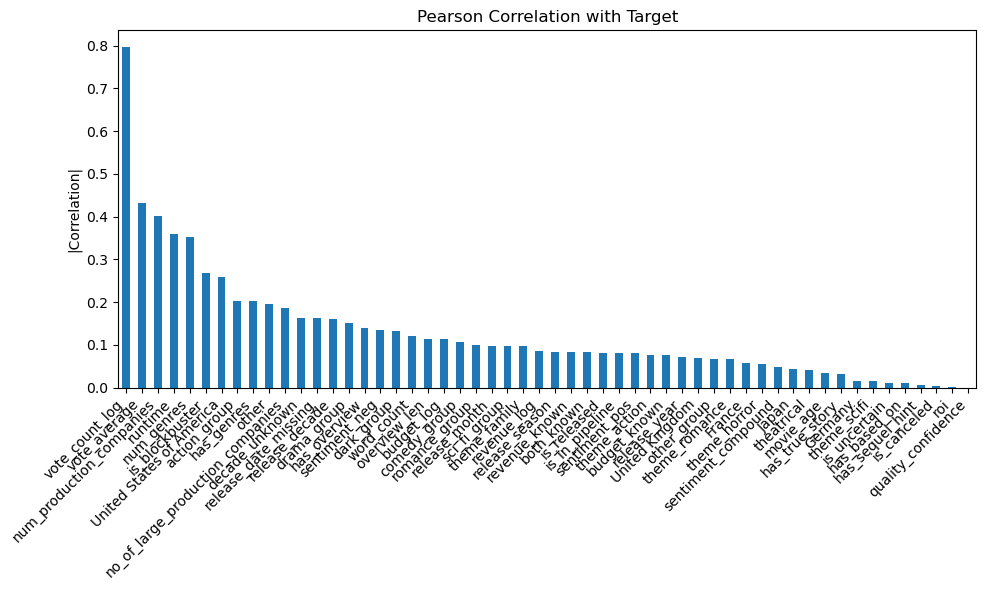

In [291]:
plt.figure(figsize=(10, 6))
correlations.plot(kind='bar')
plt.title("Pearson Correlation with Target")
plt.ylabel("|Correlation|")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [292]:
print("\n=== Mutual Information with Target ===")
X_train_filled = X_train[numeric_cols].fillna(0)
mi_scores = mutual_info_regression(X_train_filled, y_train, random_state=42)
mi_df = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)
print(mi_df)


=== Mutual Information with Target ===
vote_count_log                      0.401892
vote_average                        0.285931
release_year                        0.228560
movie_age                           0.225536
budget_log                          0.182467
revenue_log                         0.178505
runtime                             0.171629
release_decade                      0.124064
num_genres                          0.090933
num_production_companies            0.085418
has_genres                          0.049735
release_month                       0.044627
overview_len                        0.039801
release_date_missing                0.039331
word_count                          0.037888
decade_unknown                      0.037506
United States of America            0.033352
sentiment_compound                  0.027876
other                               0.026708
drama_group                         0.024437
release_season                      0.024069
sentiment_neg  

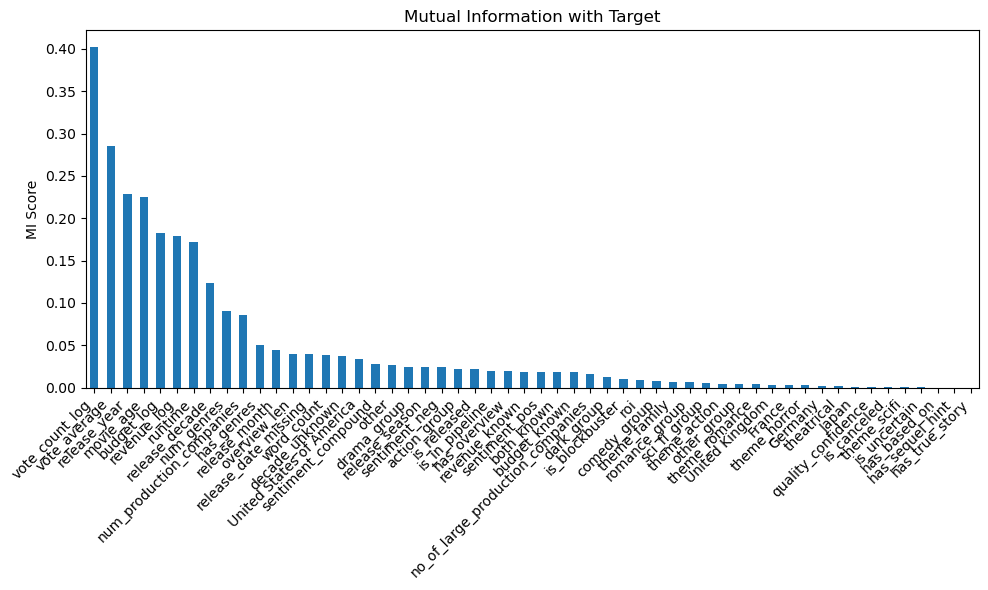

In [293]:
plt.figure(figsize=(10, 6))
mi_df.plot(kind='bar')
plt.title("Mutual Information with Target")
plt.ylabel("MI Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [294]:
print("\n=== ANOVA F-scores (binary/categorical features) ===")
binary_cols = [col for col in numeric_cols if X_train[col].nunique() <= 10]
anova_results = {}
for col in binary_cols:
    groups = [y_train[X_train[col] == val].values for val in X_train[col].unique()]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        anova_results[col] = {'F-stat': round(f_stat, 4), 'p-value': round(p_val, 6)}

anova_df = pd.DataFrame(anova_results).T.sort_values('F-stat', ascending=False)
print(anova_df)



=== ANOVA F-scores (binary/categorical features) ===
                                      F-stat   p-value
is_blockbuster                    57322.2216  0.000000
United States of America          52802.8327  0.000000
action_group                      31688.5363  0.000000
has_genres                        31432.7921  0.000000
other                             29198.8501  0.000000
release_date_missing              20016.3598  0.000000
decade_unknown                    20016.3598  0.000000
drama_group                       17391.5410  0.000000
has_overview                      14607.4887  0.000000
dark_group                        13245.8242  0.000000
comedy_group                       8374.5975  0.000000
romance_group                      7548.9402  0.000000
sci_fi_group                       7027.0658  0.000000
theme_family                       6967.7903  0.000000
no_of_large_production_companies   5378.7666  0.000000
revenue_known                      5084.2580  0.000000
both_known 

In [295]:
print("\n=== Low Variance Features (might be useless) ===")
variances = X_train[numeric_cols].var().sort_values()
low_var = variances[variances < 0.01]
print(low_var if len(low_var) > 0 else "No low variance features")



=== Low Variance Features (might be useless) ===
quality_confidence    0.000000
is_canceled           0.000167
is_uncertain          0.000305
has_sequel_hint       0.002574
is_blockbuster        0.002776
has_true_story        0.003159
sentiment_pos         0.009496
dtype: float64


In [296]:
print("\n=== Highly Correlated Feature Pairs (|r| > 0.85) ===")
corr_matrix = X_train[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, round(upper.loc[row, col], 3))
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] > 0.85]
if high_corr:
    for pair in sorted(high_corr, key=lambda x: -x[2]):
        print(f"{pair[0]} <-> {pair[1]}: {pair[2]}")
else:
    print("No highly correlated pairs")



=== Highly Correlated Feature Pairs (|r| > 0.85) ===
decade_unknown <-> release_date_missing: 1.0
both_known <-> revenue_known: 1.0
release_decade <-> release_date_missing: 0.999
decade_unknown <-> release_decade: 0.999
word_count <-> overview_len: 0.994
is_in_pipeline <-> is_released: 0.993
revenue_log <-> budget_log: 0.971
revenue_log <-> is_released: 0.964
revenue_log <-> revenue_known: 0.964
revenue_log <-> both_known: 0.964
revenue_log <-> is_in_pipeline: 0.958
budget_known <-> is_released: 0.942
budget_known <-> is_in_pipeline: 0.936
revenue_log <-> budget_known: 0.91
budget_log <-> revenue_known: 0.894
budget_log <-> both_known: 0.894


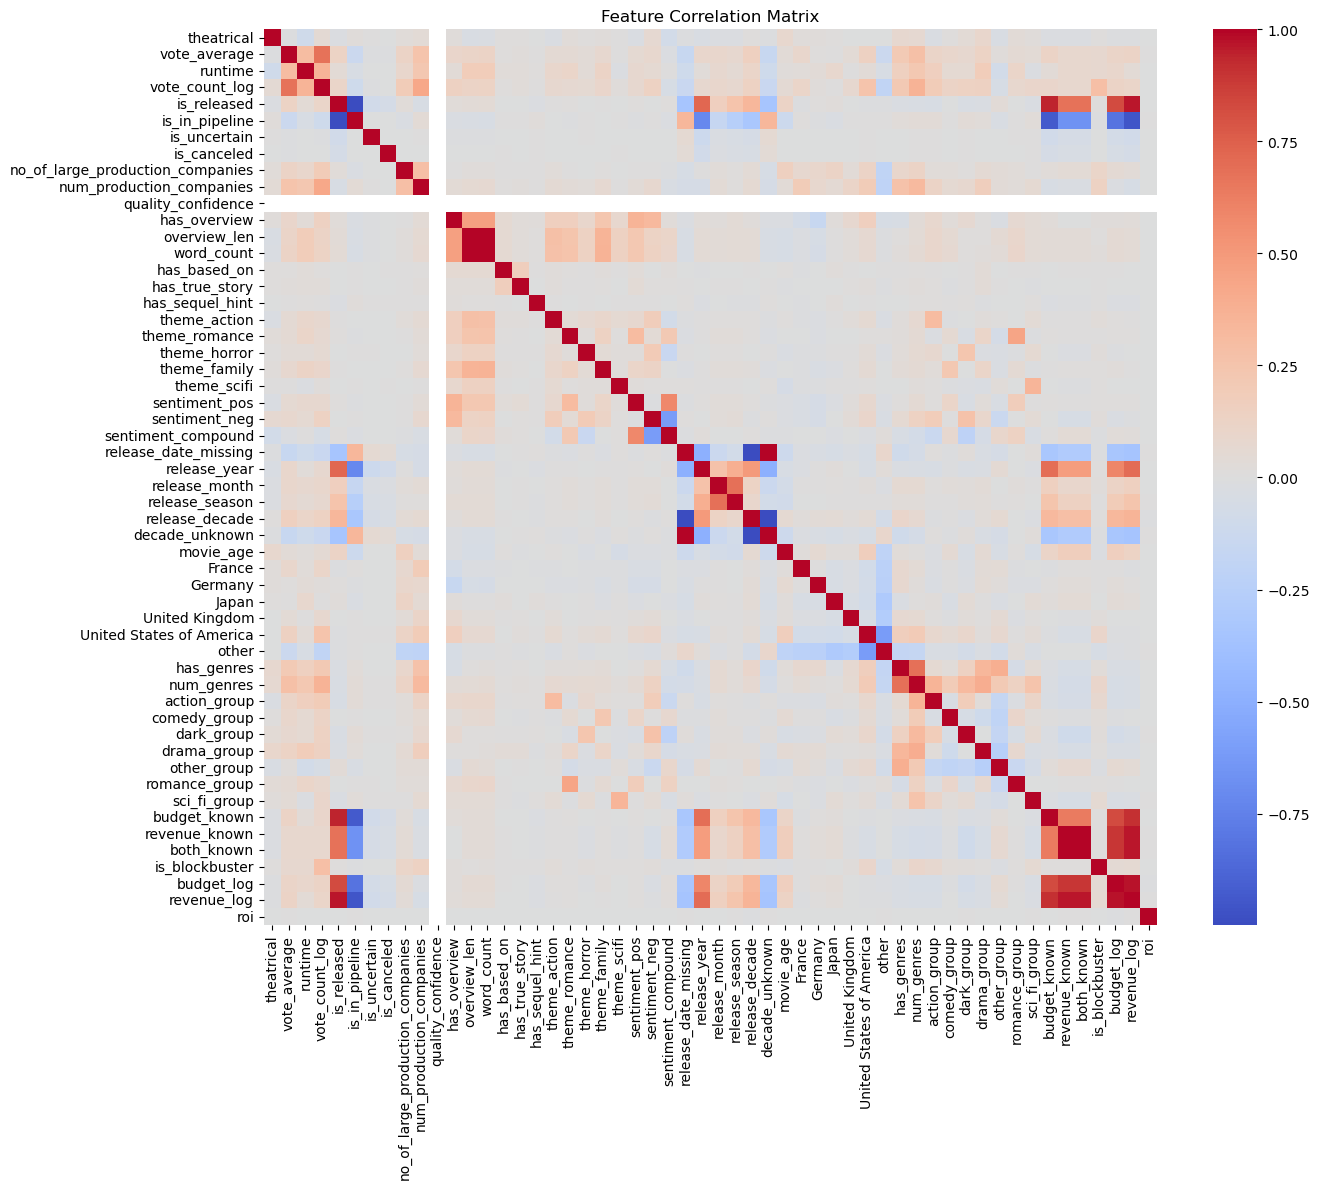

In [297]:
plt.figure(figsize=(14, 12))
sns.heatmap(X_train[numeric_cols].corr(), cmap='coolwarm', center=0, fmt='.1f')
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

##Feature Selection


In [298]:
bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)

### CV-based feature importance


In [316]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')



In [311]:

# cols_to_drop = X_train.select_dtypes(include='object').columns.tolist()
# print(f"Dropping object columns: {cols_to_drop}")
# X_train = X_train.drop(columns=cols_to_drop)
# X_test  = X_test.drop(columns=cols_to_drop)

In [312]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [313]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, n_jobs=-1, random_state=42, verbose=-1
)

In [314]:
fold_importances = np.zeros(X_train.shape[1])

In [315]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    lgb_model.fit(X_tr, y_tr)
    fold_importances += lgb_model.feature_importances_
    val_r2 = r2_score(y_val, lgb_model.predict(X_val))
    print(f"  Fold {fold+1} val R²: {val_r2:.4f}")

  Fold 1 val R²: 0.7716
  Fold 2 val R²: 0.7701
  Fold 3 val R²: 0.7722
  Fold 4 val R²: 0.7731
  Fold 5 val R²: 0.7647


In [317]:
fold_importances /= 5

In [318]:
cv_imp_df = pd.DataFrame({
    'feature': X_train.columns,
    'cv_importance': fold_importances
}).sort_values('cv_importance', ascending=False).reset_index(drop=True)

In [319]:
print(f"\nTop 20 features by CV importance:")
print(cv_imp_df.head(20).to_string())


Top 20 features by CV importance:
                     feature  cv_importance
0               release_year         2092.6
1             vote_count_log         1390.4
2                    runtime         1143.6
3               vote_average          842.8
4                revenue_log          777.6
5                  movie_age          728.6
6                 budget_log          660.6
7              release_month          616.8
8                        roi          560.6
9               overview_len          553.0
10  num_production_companies          530.4
11                word_count          475.0
12                num_genres          471.2
13             sentiment_pos          336.8
14             sentiment_neg          323.0
15                   lang_ja          312.0
16               other_group          308.2
17        sentiment_compound          307.6
18                   lang_en          284.2
19            release_decade          277.6


<Figure size 1200x600 with 0 Axes>

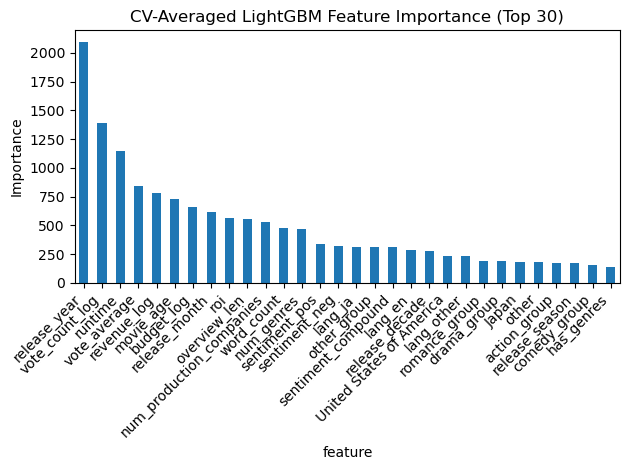

In [320]:
plt.figure(figsize=(12, 6))
cv_imp_df.head(30).plot(x='feature', y='cv_importance', kind='bar', legend=False)
plt.title("CV-Averaged LightGBM Feature Importance (Top 30)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Permutations importance

In [321]:
lgb_model.fit(X_train, y_train)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
              n_estimators=300, n_jobs=-1, num_leaves=63, random_state=42,
              reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, verbose=-1)

In [322]:
sample_idx = np.random.choice(len(X_train), size=50_000, replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

perm_imp = permutation_importance(
    lgb_model, X_sample, y_sample,
    n_repeats=5, random_state=42, n_jobs=-1
)

In [323]:
perm_df = pd.DataFrame({
    'feature': X_train.columns,
    'perm_importance_mean': perm_imp.importances_mean,
    'perm_importance_std':  perm_imp.importances_std
}).sort_values('perm_importance_mean', ascending=False).reset_index(drop=True)

In [324]:
print(f"\nTop 20 features by permutation importance:")
print(perm_df.head(20).to_string())


Top 20 features by permutation importance:
                     feature  perm_importance_mean  perm_importance_std
0             vote_count_log              0.958179             0.005978
1               release_year              0.074311             0.000890
2                    runtime              0.024511             0.000607
3              release_month              0.018854             0.000921
4               vote_average              0.016966             0.000587
5                  movie_age              0.015008             0.000403
6             release_decade              0.008560             0.000309
7             release_season              0.005308             0.000111
8                 num_genres              0.004569             0.000153
9   num_production_companies              0.004515             0.000247
10  United States of America              0.004443             0.000194
11               other_group              0.003377             0.000146
12            is_in_

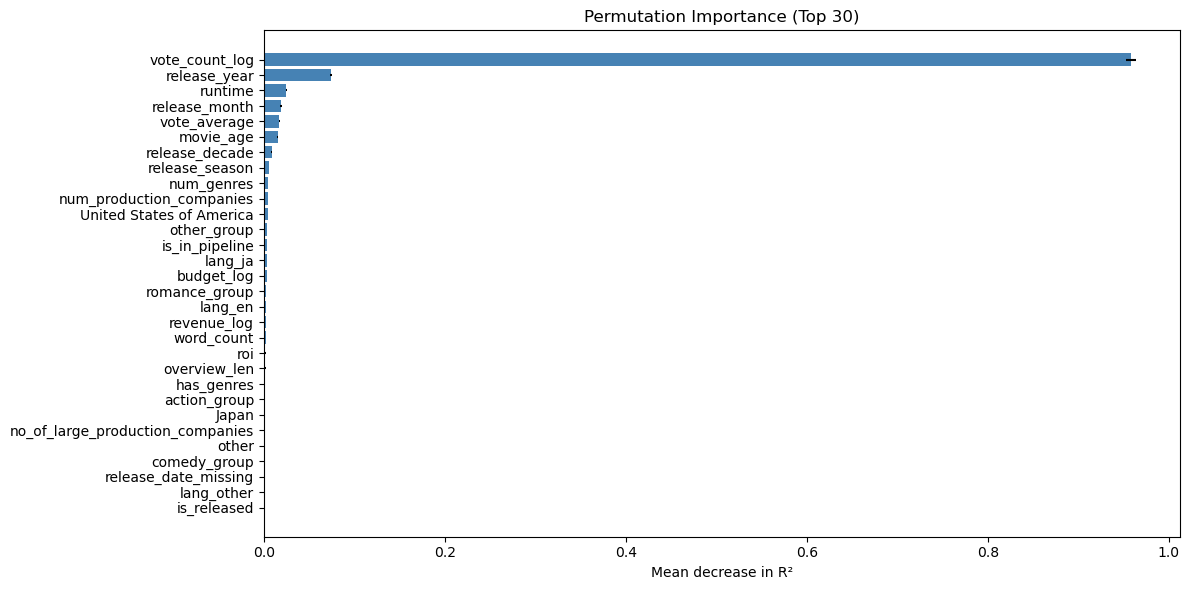

In [325]:
plt.figure(figsize=(12, 6))
top_perm = perm_df.head(30)
plt.barh(top_perm['feature'][::-1], top_perm['perm_importance_mean'][::-1],
         xerr=top_perm['perm_importance_std'][::-1], color='steelblue')
plt.title("Permutation Importance (Top 30)")
plt.xlabel("Mean decrease in R²")
plt.tight_layout()
plt.show()

### Lasso

In [326]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [327]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 738084 entries, 384703 to 122582
Data columns (total 60 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   theatrical                        738084 non-null  int32  
 1   vote_average                      738084 non-null  float64
 2   runtime                           738084 non-null  float64
 3   vote_count_log                    738084 non-null  float64
 4   lang_de                           738084 non-null  int32  
 5   lang_en                           738084 non-null  int32  
 6   lang_es                           738084 non-null  int32  
 7   lang_fr                           738084 non-null  int32  
 8   lang_ja                           738084 non-null  int32  
 9   lang_other                        738084 non-null  int32  
 10  is_released                       738084 non-null  int32  
 11  is_in_pipeline                    738084 non-null  i

In [328]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [329]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [330]:
lasso_cv = LassoCV(cv=5, max_iter=5000, random_state=42, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)

LassoCV(cv=5, max_iter=5000, n_jobs=-1, random_state=42)

In [331]:
lasso_df = pd.DataFrame({
    'feature': X_train.columns,
    'lasso_coef': np.abs(lasso_cv.coef_)
}).sort_values('lasso_coef', ascending=False).reset_index(drop=True)

In [332]:
lasso_selected = lasso_df[lasso_df['lasso_coef'] > 0]
lasso_zeroed   = lasso_df[lasso_df['lasso_coef'] == 0]

In [333]:
print(f"Best alpha: {lasso_cv.alpha_:.6f}")
print(f"Features kept: {len(lasso_selected)} / {len(lasso_df)}")
print(f"Features zeroed out: {len(lasso_zeroed)}")
print(f"\nTop 20 by Lasso coefficient:")
print(lasso_selected.head(20).to_string())
print(f"\nZeroed out (candidates to drop):")
print(lasso_zeroed['feature'].tolist())

Best alpha: 0.000382
Features kept: 44 / 60
Features zeroed out: 16

Top 20 by Lasso coefficient:
                             feature  lasso_coef
0                     vote_count_log    0.392506
1                       vote_average    0.089959
2                            runtime    0.038017
3                         num_genres    0.032865
4                     release_decade    0.026715
5           United States of America    0.021614
6           num_production_companies    0.021137
7                        other_group    0.020411
8                              Japan    0.014368
9                         budget_log    0.013127
10                      budget_known    0.012624
11                         movie_age    0.009493
12                    is_blockbuster    0.008525
13                    release_season    0.007953
14                           lang_es    0.007868
15                     romance_group    0.007734
16                        dark_group    0.007584
17  no_of_large_prod

### Consensus ranking

In [334]:
def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-10)

combined = cv_imp_df.set_index('feature').join(
    perm_df.set_index('feature')[['perm_importance_mean']]
).join(
    lasso_df.set_index('feature')[['lasso_coef']]
)

combined['cv_norm']    = normalize(combined['cv_importance'])
combined['perm_norm']  = normalize(combined['perm_importance_mean'])
combined['lasso_norm'] = normalize(combined['lasso_coef'])
combined['consensus']  = (combined['cv_norm'] + combined['perm_norm'] + combined['lasso_norm']) / 3
combined = combined.sort_values('consensus', ascending=False)

print(combined[['cv_norm', 'perm_norm', 'lasso_norm', 'consensus']].head(30).round(3).to_string())

low_consensus = combined[combined['consensus'] < 0.05]
print(f"\nWeak features (consensus < 0.05) — candidates to drop:")
print(low_consensus.index.tolist())

                                  cv_norm  perm_norm  lasso_norm  consensus
feature                                                                    
vote_count_log                      0.664      1.000       1.000      0.888
release_year                        1.000      0.078       0.000      0.359
runtime                             0.546      0.026       0.097      0.223
vote_average                        0.403      0.018       0.229      0.217
movie_age                           0.348      0.016       0.024      0.129
revenue_log                         0.372      0.002       0.000      0.125
budget_log                          0.316      0.003       0.033      0.117
release_month                       0.295      0.020       0.007      0.107
num_genres                          0.225      0.005       0.084      0.105
num_production_companies            0.253      0.005       0.054      0.104
roi                                 0.268      0.002       0.000      0.090
overview_len

### Hyperparameter Tuning

In [335]:
top_features = combined.head(40).index.tolist()
X_train_top  = X_train[top_features]
X_test_top   = X_test[top_features]


In [336]:
from sklearn.model_selection import RandomizedSearchCV


In [337]:
sample_idx    = np.random.choice(len(X_train_top), size=100_000, replace=False)
X_tune_sample = X_train_top.iloc[sample_idx]
y_tune_sample = y_train.iloc[sample_idx]

In [338]:
param_dist = {
    'n_estimators': [200, 400],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'subsample': [0.8, 1.0],
}

In [339]:
search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [340]:
search.fit(X_tune_sample, y_tune_sample)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=LGBMRegressor(n_jobs=1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.05, 0.1],
                                        'n_estimators': [200, 400],
                                        'num_leaves': [31, 63],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [341]:
print(f"\nBest params: {search.best_params_}")
print(f"Best CV R²:  {search.best_score_:.4f}")


Best params: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 200, 'learning_rate': 0.05}
Best CV R²:  0.7604


In [342]:
best_model = search.best_estimator_
test_r2 = r2_score(y_test, best_model.predict(X_test_top))
print(f"Test R²:     {test_r2:.4f}")

Test R²:     0.7698


In [343]:
print("\n" + "=" * 60)
print("FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f"Total features:              {X_train.shape[1]}")
print(f"Lasso kept:                  {len(lasso_selected)}")
print(f"Consensus top 40 selected:   {len(top_features)}")
print(f"Best tuned model Test R²:    {test_r2:.4f}")
print(f"\nTop 15 consensus features:")
for i, feat in enumerate(top_features[:15], 1):
    print(f"  {i:2}. {feat}")


FEATURE SELECTION SUMMARY
Total features:              60
Lasso kept:                  44
Consensus top 40 selected:   40
Best tuned model Test R²:    0.7698

Top 15 consensus features:
   1. vote_count_log
   2. release_year
   3. runtime
   4. vote_average
   5. movie_age
   6. revenue_log
   7. budget_log
   8. release_month
   9. num_genres
  10. num_production_companies
  11. roi
  12. overview_len
  13. word_count
  14. release_decade
  15. other_group


###Feature Selection


In [344]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [345]:
drop_redundant = [
    'word_count',           # correlated with overview_len
    'release_date_missing', # correlated with decade_unknown
    'both_known',           # correlated with revenue_known
    'budget_log',           # correlated with revenue_log
    'movie_age',            # correlated with release_year
]

In [346]:
top_features_clean = [f for f in top_features if f not in drop_redundant]
X_train_final = X_train[top_features_clean]
X_test_final  = X_test[top_features_clean]

In [347]:
print(f"Features before cleaning: {len(top_features)}")
print(f"Features after cleaning:  {len(top_features_clean)}")
print(f"Dropped: {drop_redundant}")
print(f"\nFinal features: {top_features_clean}")

Features before cleaning: 40
Features after cleaning:  37
Dropped: ['word_count', 'release_date_missing', 'both_known', 'budget_log', 'movie_age']

Final features: ['vote_count_log', 'release_year', 'runtime', 'vote_average', 'revenue_log', 'release_month', 'num_genres', 'num_production_companies', 'roi', 'overview_len', 'release_decade', 'other_group', 'United States of America', 'sentiment_pos', 'sentiment_neg', 'lang_en', 'lang_ja', 'sentiment_compound', 'Japan', 'romance_group', 'lang_other', 'release_season', 'drama_group', 'action_group', 'comedy_group', 'other', 'no_of_large_production_companies', 'lang_es', 'has_genres', 'dark_group', 'France', 'United Kingdom', 'budget_known', 'Germany', 'theatrical', 'sci_fi_group', 'lang_fr']


##Model Train

In [348]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [362]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import lightgbm as lgb
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [365]:
results = []

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    test_pred  = model.predict(X_te)

    train_r2     = r2_score(y_tr, train_pred)
    test_r2      = r2_score(y_te, test_pred)
    test_r2_orig = r2_score(np.expm1(y_te), np.expm1(test_pred))
    test_rmse    = np.sqrt(mean_squared_error(y_te, test_pred))
    test_mae     = mean_absolute_error(y_te, test_pred)
    overfit      = train_r2 - test_r2

    print(f"\n{'─'*52}")
    print(f"  {name}")
    print(f"{'─'*52}")
    print(f"  Train R²        : {train_r2:.4f}")
    print(f"  Test  R² (log)  : {test_r2:.4f}")
    print(f"  Test  R² (orig) : {test_r2_orig:.4f}")
    print(f"  Test  RMSE      : {test_rmse:.4f}")
    print(f"  Test  MAE       : {test_mae:.4f}")
    print(f"  Overfit gap     : {overfit:+.4f}", end='')
    if overfit > 0.1:    print('overfit')
    elif overfit < -0.02: print('unstable')
    else:                print('')

    results.append({
        'Model'         : name,
        'Train R²'      : round(train_r2, 4),
        'Test R² (log)' : round(test_r2, 4),
        'Test R² (orig)': round(test_r2_orig, 4),
        'RMSE'          : round(test_rmse, 4),
        'MAE'           : round(test_mae, 4),
        'Overfit gap'   : round(overfit, 4),
    })
    return model

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

ridge_model=evaluate('Ridge Regression',
         Ridge(alpha=1.0),
         X_train_scaled, y_train, X_test_scaled, y_test)

lasso_model=evaluate('Lasso Regression',
         Lasso(alpha=0.001, max_iter=5000),
         X_train_scaled, y_train, X_test_scaled, y_test)

# random forest
sample_idx_rf = np.random.choice(len(X_train_final), size=200_000, replace=False)
X_train_rf = X_train_final.iloc[sample_idx_rf]
y_train_rf = y_train.iloc[sample_idx_rf]

# tuned lightgb
lgb_model = lgb.LGBMRegressor(
    subsample=0.8, num_leaves=63,
    n_estimators=400, learning_rate=0.05,
    random_state=42, verbose=-1, n_jobs=-1
)
evaluate('LightGBM (tuned)',
         lgb_model,
         X_train_final, y_train, X_test_final, y_test)

evaluate('Random Forest',
         RandomForestRegressor(n_estimators=100, max_depth=15,
                               min_samples_leaf=5, n_jobs=-1, random_state=42),
         X_train_rf, y_train_rf, X_test_final, y_test)



────────────────────────────────────────────────────
  Ridge Regression
────────────────────────────────────────────────────
  Train R²        : 0.6781
  Test  R² (log)  : 0.6792
  Test  R² (orig) : 0.6170
  Test  RMSE      : 0.2713
  Test  MAE       : 0.1805
  Overfit gap     : -0.0011

────────────────────────────────────────────────────
  Lasso Regression
────────────────────────────────────────────────────
  Train R²        : 0.6778
  Test  R² (log)  : 0.6791
  Test  R² (orig) : 0.6138
  Test  RMSE      : 0.2714
  Test  MAE       : 0.1801
  Overfit gap     : -0.0012

────────────────────────────────────────────────────
  LightGBM (tuned)
────────────────────────────────────────────────────
  Train R²        : 0.7874
  Test  R² (log)  : 0.7790
  Test  R² (orig) : 0.7270
  Test  RMSE      : 0.2252
  Test  MAE       : 0.1423
  Overfit gap     : +0.0084

────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────
  Train R²

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_jobs=-1,
                      random_state=42)

In [366]:
from xgboost import XGBRegressor
XGB_modell=evaluate('XGBoost',
         XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8,
                      n_jobs=-1, random_state=42, verbosity=0),
         X_train_final, y_train, X_test_final, y_test)


────────────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────────────
  Train R²        : 0.7806
  Test  R² (log)  : 0.7748
  Test  R² (orig) : 0.7313
  Test  RMSE      : 0.2273
  Test  MAE       : 0.1434
  Overfit gap     : +0.0059


In [367]:
lgb_F = lgb.LGBMRegressor(
    subsample=0.8, num_leaves=63,
    n_estimators=1000, learning_rate=0.05,
    random_state=42, verbose=-1, n_jobs=-1
)
final_lgb=evaluate('LightGBM (1000 trees)',
         lgb_F,
         X_train_final, y_train, X_test_final, y_test)


────────────────────────────────────────────────────
  LightGBM (1000 trees)
────────────────────────────────────────────────────
  Train R²        : 0.8003
  Test  R² (log)  : 0.7814
  Test  R² (orig) : 0.7308
  Test  RMSE      : 0.2240
  Test  MAE       : 0.1417
  Overfit gap     : +0.0189


In [368]:
rf_model=evaluate('Random Forest (50)',
         RandomForestRegressor(n_estimators=50, max_depth=15,
                               min_samples_leaf=5, n_jobs=-1, random_state=42),
         X_train_final, y_train, X_test_final, y_test)


────────────────────────────────────────────────────
  Random Forest (50)
────────────────────────────────────────────────────
  Train R²        : 0.8004
  Test  R² (log)  : 0.7731
  Test  R² (orig) : 0.7230
  Test  RMSE      : 0.2282
  Test  MAE       : 0.1427
  Overfit gap     : +0.0273


                Model  Train R²  Test R² (log)  Test R² (orig)   RMSE    MAE  Overfit gap
              XGBoost    0.7806         0.7748          0.7313 0.2273 0.1434       0.0059
LightGBM (1000 trees)    0.8003         0.7814          0.7308 0.2240 0.1417       0.0189
     LightGBM (tuned)    0.7874         0.7790          0.7270 0.2252 0.1423       0.0084
   Random Forest (50)    0.8004         0.7731          0.7230 0.2282 0.1427       0.0273
        Random Forest    0.8184         0.7667          0.7065 0.2313 0.1439       0.0516
     Ridge Regression    0.6781         0.6792          0.6170 0.2713 0.1805      -0.0011
     Lasso Regression    0.6778         0.6791          0.6138 0.2714 0.1801      -0.0012


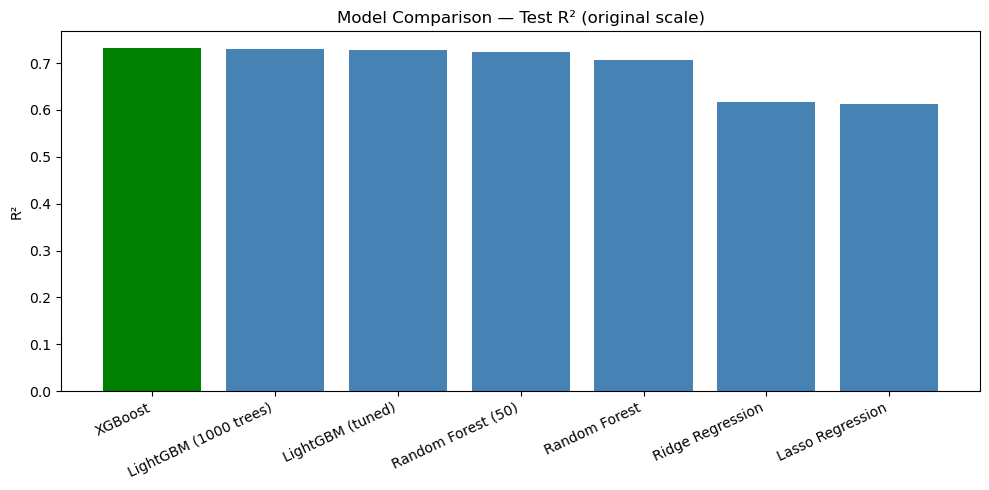

In [369]:
results_df = pd.DataFrame(results).sort_values('Test R² (orig)', ascending=False)
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['green' if r == results_df['Test R² (orig)'].max()
          else 'steelblue' for r in results_df['Test R² (orig)']]
plt.bar(results_df['Model'], results_df['Test R² (orig)'], color=colors)
plt.title("Model Comparison — Test R² (original scale)")
plt.ylabel("R²")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

Best model: XGBoost

Top 20 highest actual popularity movies:
    actual  predicted  abs_error  pct_error
0   99.944  21.777220  78.166780  78.210577
1   98.545  40.959864  57.585136  58.435370
2   97.888  52.471262  45.416738  46.396634
3   96.944   5.822798  91.121202  93.993647
4   96.565  52.921129  43.643871  45.196365
5   96.530  68.351256  28.178744  29.191696
6   96.283  52.277861  44.005139  45.703954
7   95.297   6.423609  88.873391  93.259378
8   94.447   1.623027  92.823973  98.281546
9   94.130  17.148138  76.981862  81.782494
10  93.974  39.214025  54.759975  58.271409
11  92.533  34.514792  58.018208  62.700018
12  90.378  38.326525  52.051475  57.593081
13  89.985  55.312180  34.672820  38.531777
14  89.799  22.850602  66.948398  74.553611
15  89.699  45.159921  44.539079  49.653930
16  89.408  13.456381  75.951619  84.949466
17  88.767  25.537221  63.229779  71.231176
18  86.737  14.195543  72.541457  83.633808
19  85.420  42.305350  43.114650  50.473717

Error by popu

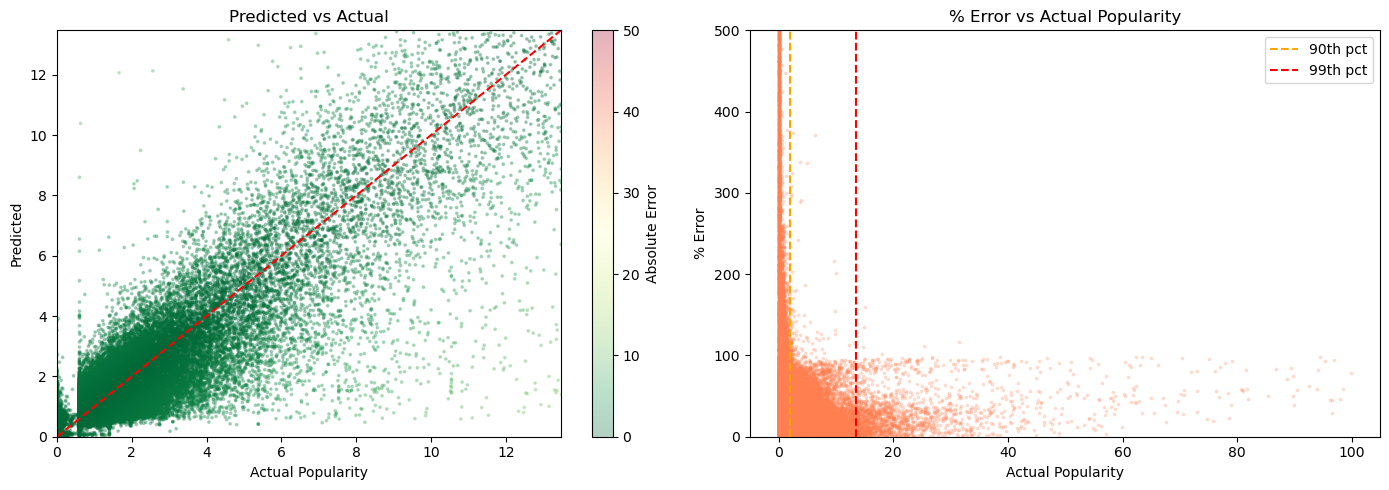

In [370]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")

best_preds = final_lgb.predict(X_test_final)

error_df = pd.DataFrame({
    'actual':    np.expm1(y_test),
    'predicted': np.expm1(best_preds),
})
error_df['abs_error'] = np.abs(error_df['actual'] - error_df['predicted'])
error_df['pct_error'] = error_df['abs_error'] / (error_df['actual'] + 1e-6) * 100
error_df = error_df.sort_values('actual', ascending=False).reset_index(drop=True)

print("\nTop 20 highest actual popularity movies:")
print(error_df.head(20).to_string())

error_df['percentile_bin'] = pd.qcut(error_df['actual'], q=10, duplicates='drop')
bin_stats = error_df.groupby('percentile_bin', observed=True).agg(
    count       =('actual', 'count'),
    avg_actual  =('actual', 'mean'),
    avg_pred    =('predicted', 'mean'),
    avg_abs_err =('abs_error', 'mean'),
    avg_pct_err =('pct_error', 'mean'),
    r2          =('actual', lambda x: r2_score(x, error_df.loc[x.index, 'predicted']))
).round(3)
print("\nError by popularity percentile:")
print(bin_stats.to_string())

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sc = plt.scatter(error_df['actual'], error_df['predicted'],
                 c=error_df['abs_error'], cmap='RdYlGn_r',
                 alpha=0.3, s=3, norm=plt.Normalize(0, 50))
plt.colorbar(sc, label='Absolute Error')
lim = [0, error_df['actual'].quantile(0.99)]
plt.xlim(lim); plt.ylim(lim)
plt.plot(lim, lim, 'r--', linewidth=1.5)
plt.xlabel('Actual Popularity'); plt.ylabel('Predicted')
plt.title('Predicted vs Actual')

plt.subplot(1, 2, 2)
plt.scatter(error_df['actual'], error_df['pct_error'],
            alpha=0.2, s=3, color='coral')
plt.axvline(error_df['actual'].quantile(0.9),  color='orange',
            linestyle='--', label='90th pct')
plt.axvline(error_df['actual'].quantile(0.99), color='red',
            linestyle='--', label='99th pct')
plt.xlabel('Actual Popularity'); plt.ylabel('% Error')
plt.title('% Error vs Actual Popularity')
plt.legend(); plt.ylim(0, 500)
plt.tight_layout()
plt.show()

### Saving The Models


In [371]:
import pickle

In [372]:
pickle.dump(imputer,       open('imputer.pkl',       'wb'))
pickle.dump(model_runtime, open('model_runtime.pkl', 'wb'))
pickle.dump(mlb_countries, open('mlb_countries.pkl', 'wb'))
pickle.dump(mlb_genres,    open('mlb_genres.pkl',    'wb'))
pickle.dump(scaler,        open('scaler.pkl',        'wb')) 

In [373]:
pickle.dump(top_langs,          open('top_langs.pkl',          'wb'))
pickle.dump(top_companies,      open('top_companies.pkl',      'wb'))
pickle.dump(top5_countries,     open('top5_countries.pkl',     'wb'))
pickle.dump(top_features_clean, open('top_features_clean.pkl', 'wb'))
pickle.dump(train_age_median,   open('train_age_median.pkl',   'wb'))
pickle.dump(roi_median,         open('roi_median.pkl',         'wb'))


In [374]:
pickle.dump(ridge_model,  open('model_ridge.pkl',  'wb'))
pickle.dump(lasso_model,  open('model_lasso.pkl',  'wb'))
pickle.dump(XGB_modell,     open('model_XGB.pkl', 'wb'))

In [375]:
pickle.dump(rf_model,     open('model_rf.pkl',     'wb'))
pickle.dump(final_lgb,    open('model_lgb1000.pkl','wb'))